# Treino dos modelos — D+1 e D+7 por série

Consome a camada silver e grava a camada gold. **Não repete o diagnóstico** já fechado em
`data_exploration.ipynb` (dimensionamento, quebra estrutural, concentração IC/template,
correlação cruzada, decomposição nível×fração, maturação de rótulo) — quando um desses achados
é necessário para justificar uma decisão, ele é **citado**, não recalculado.

| | |
|---|---|
| **Entrada** | `2_silver_data/s_fato_diario_prioridade.csv` · `2_silver_data/s_dim_calendario.csv` |
| **Saída** | `3_gold_data/g_previsoes.csv` · `3_gold_data/g_avaliacao_modelos.csv` · `3_gold_data/data_dictionary.md` |
| **Alvo** | `abertos` — 6 séries (P2/P3/P4 × com_intervencao/sem_intervencao) |
| **Horizontes** | D+1 (modelo) e D+7 (recursão do mesmo modelo) |

## Mapa

| Seção | O que resolve |
|---|---|
| 1 | Configuração, constantes e carga já recortada na janela de cada tipo |
| 2 | Replot da série e da autocorrelação **dentro da janela literal** — única reanálise permitida |
| 3 | Lista fechada de features, esquema de validação temporal e baselines (piso) |
| 4 | Objetivo 1 — agrupar prioridades num modelo só compensa? |
| 5 | Objetivos 2 e 3 — três candidatos por grupo de comportamento e a escolha do vencedor |
| 6 | D+7 por recursão do modelo de D+1, com o erro acumulado reportado à parte |
| 7 | Objetivo 4 — explicabilidade comparável entre os três tipos de modelo |
| 8 | Tabelas gold sob o contrato `salvar()`/`CATALOGO` |
| 9 | Checklist de encerramento |

## As duas decisões herdadas que este notebook não rediscute

**Janela de treino/teste — regra literal.** `com_intervencao` usa o ano cheio de 2025
(2025-01-01 a 2025-12-31); `sem_intervencao` usa 2025-09-01 a 2025-12-31. A mesma regra vale para
as três prioridades dentro de cada tipo. A exploração encontrou uma quebra fina em P3
com_intervencao (25/10) e o breakpoint real de sem_intervencao em 31/08–01/09: ambos são
**conscientemente ignorados** aqui. Não é bug — é a decisão de manter a regra simples e igual
entre séries, ao custo de um pedaço de janela menos homogêneo em P3.

**D+7 é recursivo.** Um único modelo, o de D+1, aplicado sete vezes realimentando a própria
previsão. Não há modelo direto de D+7 nem cadeia de modelos por passo. Isso restringe o conjunto
de features de forma dura (§3.1) e faz o erro crescer com o passo — o que é esperado e aparece
nos números da §6.

---
# 1. Configuração

## 1.1 Ambiente e caminhos

Mesma convenção de `data_exploration.ipynb`: o notebook roda local ou no Colab sem edição manual
de caminho. A leitura agora é a **silver** e a escrita é a **gold**.

In [1]:
import os
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    RAIZ = "/content/drive/MyDrive/fiap/segundo ano/challenge_locaweb/"
    BASE_PATH = RAIZ + "2_silver_data/"
    SAVE_PATH = RAIZ + "3_gold_data/"
else:
    BASE_PATH = "../2_silver_data/"
    SAVE_PATH = "../3_gold_data/"

print(f"Ambiente : {'Google Colab' if IN_COLAB else 'Local'}")
print(f"Python   : {sys.version.split()[0]}")
print(f"Leitura  : {BASE_PATH}")
print(f"Escrita  : {SAVE_PATH}")

Ambiente : Local
Python   : 3.12.10
Leitura  : ../2_silver_data/
Escrita  : ../3_gold_data/


## 1.2 Imports

In [2]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import PoissonRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)      # convergência do MLP em série curta
warnings.filterwarnings("ignore", category=RuntimeWarning)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 170)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

print(f"pandas {pd.__version__} | numpy {np.__version__} | scikit-learn {sklearn.__version__}")

pandas 2.2.2 | numpy 2.0.2 | scikit-learn 1.9.0


## 1.3 Padrão visual

O padrão é o mesmo de `data_exploration.ipynb`. Um notebook não é importável como módulo, então
`PALETA`, `novo_grafico()` e `finalizar()` são **replicados na mesma forma** — deliberadamente,
para não nascer um segundo estilo no projeto. Se o tema mudar lá, muda aqui.

In [3]:
PALETA = {
    "p2": "#C0392B",   # vermelho  — alta
    "p3": "#E67E22",   # laranja   — média
    "p4": "#F1C40F",   # amarelo   — baixa
    "total": "#2C3E50",
    "neutro": "#95A5A6",
    "destaque": "#2980B9",
    "r1": "#BDC3C7",
    "r2": "#7F8C8D",
    "r3": "#34495E",
}
COR_PRIORIDADE = {2: PALETA["p2"], 3: PALETA["p3"], 4: PALETA["p4"]}
COR_TIPO = {"com_intervencao": PALETA["destaque"], "sem_intervencao": PALETA["p2"]}

sns.set_theme(
    style="whitegrid",
    rc={
        "figure.figsize": (12, 4.5),
        "figure.dpi": 110,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.labelsize": 10,
        "axes.edgecolor": "#DDDDDD",
        "grid.color": "#EEEEEE",
        "grid.linewidth": 0.8,
        "legend.frameon": False,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    },
)


def novo_grafico(titulo, subtitulo=None, figsize=(12, 4.5), ncols=1):
    """Cria figura/eixos já titulados. Retorna (fig, ax) ou (fig, array de ax)."""
    fig, axes = plt.subplots(1, ncols, figsize=figsize)
    ax0 = axes if ncols == 1 else axes[0]
    ax0.set_title(titulo, pad=14 if subtitulo else 8)
    if subtitulo:
        ax0.text(
            0, 1.02, subtitulo, transform=ax0.transAxes,
            fontsize=9, color="#666666", va="bottom",
        )
    return fig, axes


def finalizar(fig, fonte=None):
    """Aplica layout e uma nota de rodapé opcional."""
    if fonte:
        fig.text(0.005, -0.04, fonte, fontsize=8, color="#888888")
    fig.tight_layout()
    plt.show()

## 1.4 Constantes

Tudo que é decisão de negócio ou de desenho de experimento mora aqui. Se uma regra mudar, muda
em um lugar só.

In [4]:
# --- Escopo do alvo -------------------------------------------------------
# A silver carrega P1..P5; P1 e P5 ficam fora do escopo do desafio e são cortadas
# no carregamento (§1.5), não silenciosamente no meio da modelagem.
PRIORIDADES = [2, 3, 4]
TIPOS_TRATAMENTO = ["com_intervencao", "sem_intervencao"]
SERIES = [(p, t) for p in PRIORIDADES for t in TIPOS_TRATAMENTO]   # as 6 séries alvo

# --- Janela de treino/teste (decisão herdada, literal) --------------------
JANELA_TREINO_TESTE = {
    "com_intervencao": ("2025-01-01", "2025-12-31"),   # ano cheio, 365 dias
    "sem_intervencao": ("2025-09-01", "2025-12-31"),   # 122 dias
}

# --- Horizontes -----------------------------------------------------------
HORIZONTES = ["D+1", "D+7"]
PASSO_MAXIMO = 7          # passos da recursão da §6

# --- Features do alvo (lags e janelas móveis) -----------------------------
# Mesmos lags/janelas da silver. São recalculáveis passo a passo na recursão do D+7 —
# é o que os torna elegíveis pela regra dura da §3.1.
LAGS_ALVO = (1, 2, 3, 7, 14)
JANELAS_ALVO = (7, 14, 30)

# --- Validação temporal ---------------------------------------------------
# Nº de dobras proporcional ao tamanho da janela; `test_size` fixo garante que
# nenhuma dobra treine com um punhado de dias (o primeiro treino é o gargalo em
# sem_intervencao, que só tem 122 linhas).
VALIDACAO = {
    "com_intervencao": {"n_dobras": 6, "tamanho_teste": 40},
    "sem_intervencao": {"n_dobras": 4, "tamanho_teste": 15},
}
GAP_VALIDACAO = 1         # = horizonte do modelo-base (D+1)

# --- Escolha do vencedor --------------------------------------------------
# Diferença de MAE menor que isso é empate técnico: desempata a simplicidade.
TOLERANCIA_EMPATE = 0.02  # 2 %
# Menor = mais simples. Pooled antes de individual: um modelo em produção, não três.
ORDEM_SIMPLICIDADE = {"GLM Poisson": 0, "Gradient Boosting": 1, "MLP": 2}
ORDEM_ESCOPO = {"pooled": 0, "individual": 1}

SEMENTE = 42

print(f"Séries alvo : {len(SERIES)} ({', '.join(f'P{p} {t}' for p, t in SERIES)})")
for tipo, (ini, fim) in JANELA_TREINO_TESTE.items():
    dias = (pd.Timestamp(fim) - pd.Timestamp(ini)).days + 1
    v = VALIDACAO[tipo]
    print(f"{tipo:<16}: {ini} a {fim} ({dias} dias) | "
          f"{v['n_dobras']} dobras x {v['tamanho_teste']} dias de teste, gap={GAP_VALIDACAO}")

Séries alvo : 6 (P2 com_intervencao, P2 sem_intervencao, P3 com_intervencao, P3 sem_intervencao, P4 com_intervencao, P4 sem_intervencao)
com_intervencao : 2025-01-01 a 2025-12-31 (365 dias) | 6 dobras x 40 dias de teste, gap=1
sem_intervencao : 2025-09-01 a 2025-12-31 (122 dias) | 4 dobras x 15 dias de teste, gap=1


## 1.5 Carga

Duas tabelas silver, nada mais. O filtro de prioridade acontece **no carregamento** — assim
qualquer contagem impressa depois já é a do escopo real, e não existe P1/P5 vazando para dentro
de um `groupby` mais adiante.

In [5]:
OPCOES_LEITURA = {"sep": ";", "encoding": "utf-8-sig", "parse_dates": ["data"]}

fato_prioridade = pd.read_csv(f"{BASE_PATH}s_fato_diario_prioridade.csv", **OPCOES_LEITURA)
dim_calendario = pd.read_csv(f"{BASE_PATH}s_dim_calendario.csv", **OPCOES_LEITURA)

linhas_totais = len(fato_prioridade)
fato_prioridade = fato_prioridade[fato_prioridade["prioridade"].isin(PRIORIDADES)].copy()
print(f"s_fato_diario_prioridade : {linhas_totais:,} linhas -> {len(fato_prioridade):,} "
      f"após cortar P1/P5 ({linhas_totais - len(fato_prioridade):,} descartadas)")
print(f"s_dim_calendario         : {len(dim_calendario):,} linhas x {dim_calendario.shape[1]} colunas")
print(f"Cobertura                : {fato_prioridade['data'].min():%d/%m/%Y} a "
      f"{fato_prioridade['data'].max():%d/%m/%Y}")

# Aceite do Item 0: cada série recortada na sua janela precisa ter exatamente os dias da janela.
conferencia = []
for p, tipo in SERIES:
    ini, fim = JANELA_TREINO_TESTE[tipo]
    s = fato_prioridade.query(
        "prioridade == @p and tipo_tratamento == @tipo and @ini <= data <= @fim"
    )
    esperado = (pd.Timestamp(fim) - pd.Timestamp(ini)).days + 1
    conferencia.append({
        "prioridade": p, "tipo_tratamento": tipo, "janela": f"{ini} a {fim}",
        "dias_esperados": esperado, "linhas": len(s),
        "dias_distintos": s["data"].nunique(), "grade_completa": len(s) == esperado,
        "abertos_media": s["abertos"].mean(), "abertos_max": s["abertos"].max(),
        "pct_zeros": (s["abertos"] == 0).mean() * 100,
    })
conferencia = pd.DataFrame(conferencia)
print()
print(conferencia.round(1).to_string(index=False))

assert conferencia["grade_completa"].all(), "alguma série não cobre a janela inteira"
print("\nAceite Item 0 OK — 6 séries, grade completa em cada janela.")

s_fato_diario_prioridade : 6,570 linhas -> 6,570 após cortar P1/P5 (0 descartadas)
s_dim_calendario         : 1,095 linhas x 23 colunas
Cobertura                : 02/01/2023 a 31/12/2025

 prioridade tipo_tratamento                  janela  dias_esperados  linhas  dias_distintos  grade_completa  abertos_media  abertos_max  pct_zeros
          2 com_intervencao 2025-01-01 a 2025-12-31             365     365             365            True          25.70          327       0.00
          2 sem_intervencao 2025-09-01 a 2025-12-31             122     122             122            True          51.30          660       0.00
          3 com_intervencao 2025-01-01 a 2025-12-31             365     365             365            True          63.80          188       0.00
          3 sem_intervencao 2025-09-01 a 2025-12-31             122     122             122            True         147.20          729       0.00
          4 com_intervencao 2025-01-01 a 2025-12-31             365     365  

---
# 2. Recorte por série e replot

Esta é a **única reanálise permitida** neste notebook. A exploração já plotou série e
autocorrelação, mas em janelas diferentes: lá cada série usava a janela que a detecção de quebra
liberou para ela; aqui todas usam a janela literal do enunciado (§1.4). Como o recorte mudou, o
gráfico precisa ser refeito — não para gerar achado novo, e sim para confirmar visualmente que a
regra literal não introduziu nenhuma descontinuidade grosseira que o enunciado não previu.

O que **não** se faz aqui: rodar detecção de quebra de novo, testar features novas, revisar
dimensionamento. Isso está fechado.

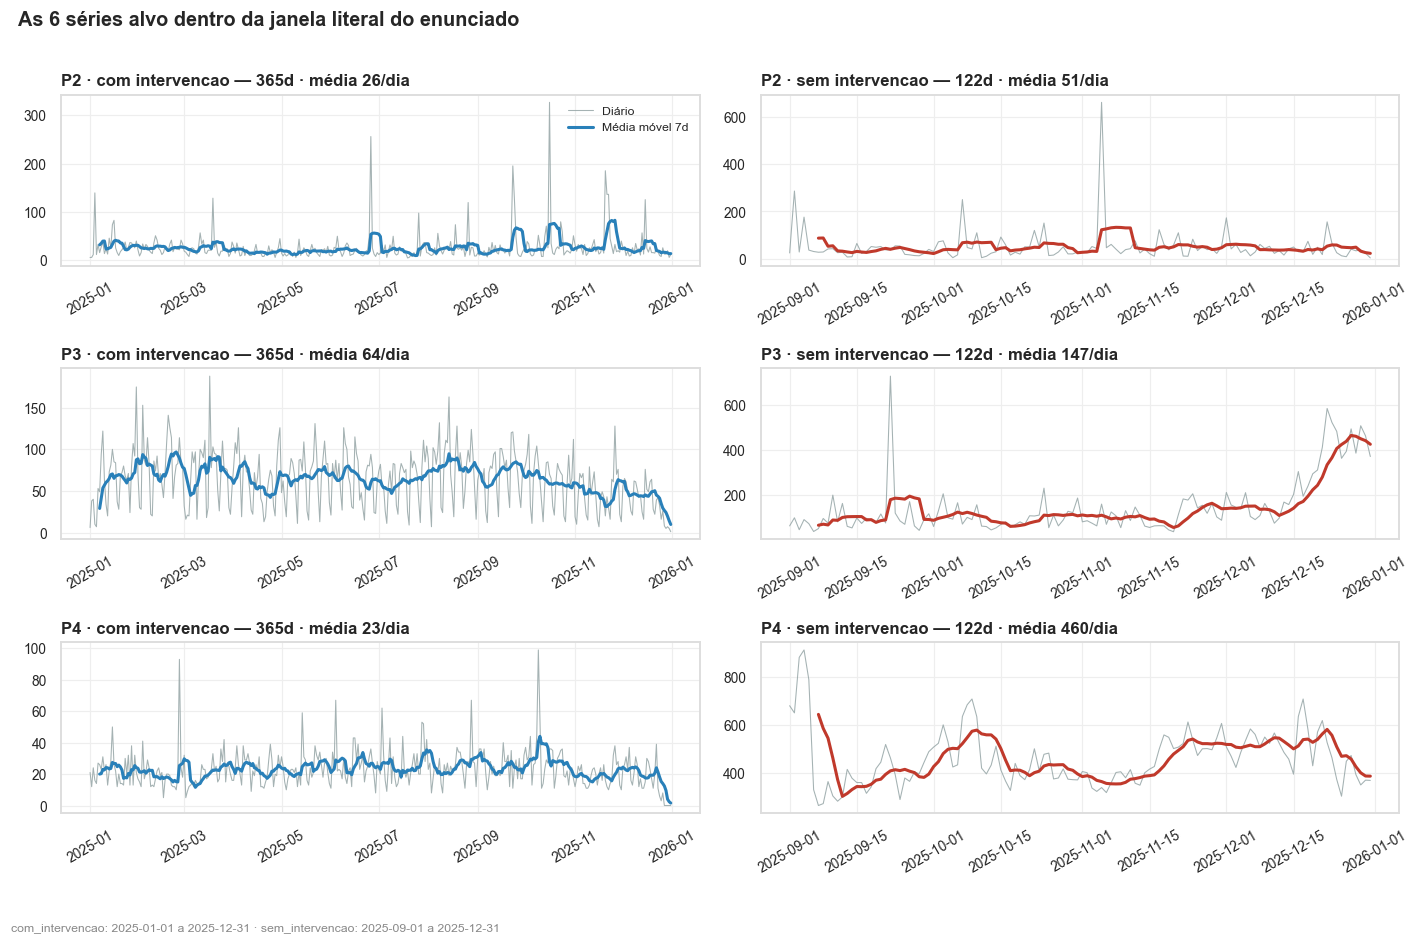

In [6]:
def recortar(prioridade, tipo, tabela=None):
    """Devolve a série `abertos` de uma das 6 séries, já recortada na janela do §1.4."""
    tabela = fato_prioridade if tabela is None else tabela
    ini, fim = JANELA_TREINO_TESTE[tipo]
    return (
        tabela.query("prioridade == @prioridade and tipo_tratamento == @tipo")
        .query("@ini <= data <= @fim")
        .sort_values("data")
        .set_index("data")["abertos"]
        .astype(float)
    )


fig, axes = plt.subplots(3, 2, figsize=(13, 8))
for i, p in enumerate(PRIORIDADES):
    for j, tipo in enumerate(TIPOS_TRATAMENTO):
        s = recortar(p, tipo)
        ax = axes[i, j]
        ax.plot(s.index, s.values, color=PALETA["neutro"], lw=0.7, alpha=0.85, label="Diário")
        ax.plot(s.index, s.rolling(7).mean(), color=COR_TIPO[tipo], lw=2, label="Média móvel 7d")
        ax.set_title(f"P{p} · {tipo.replace('_', ' ')} — {len(s)}d · média {s.mean():.0f}/dia",
                     fontsize=11)
        ax.tick_params(axis="x", rotation=30)
        if i == 0 and j == 0:
            ax.legend(fontsize=8)
fig.suptitle("As 6 séries alvo dentro da janela literal do enunciado",
             y=1.005, fontsize=13, weight="bold", x=0.01, ha="left")
finalizar(fig, "com_intervencao: 2025-01-01 a 2025-12-31 · sem_intervencao: 2025-09-01 a 2025-12-31")

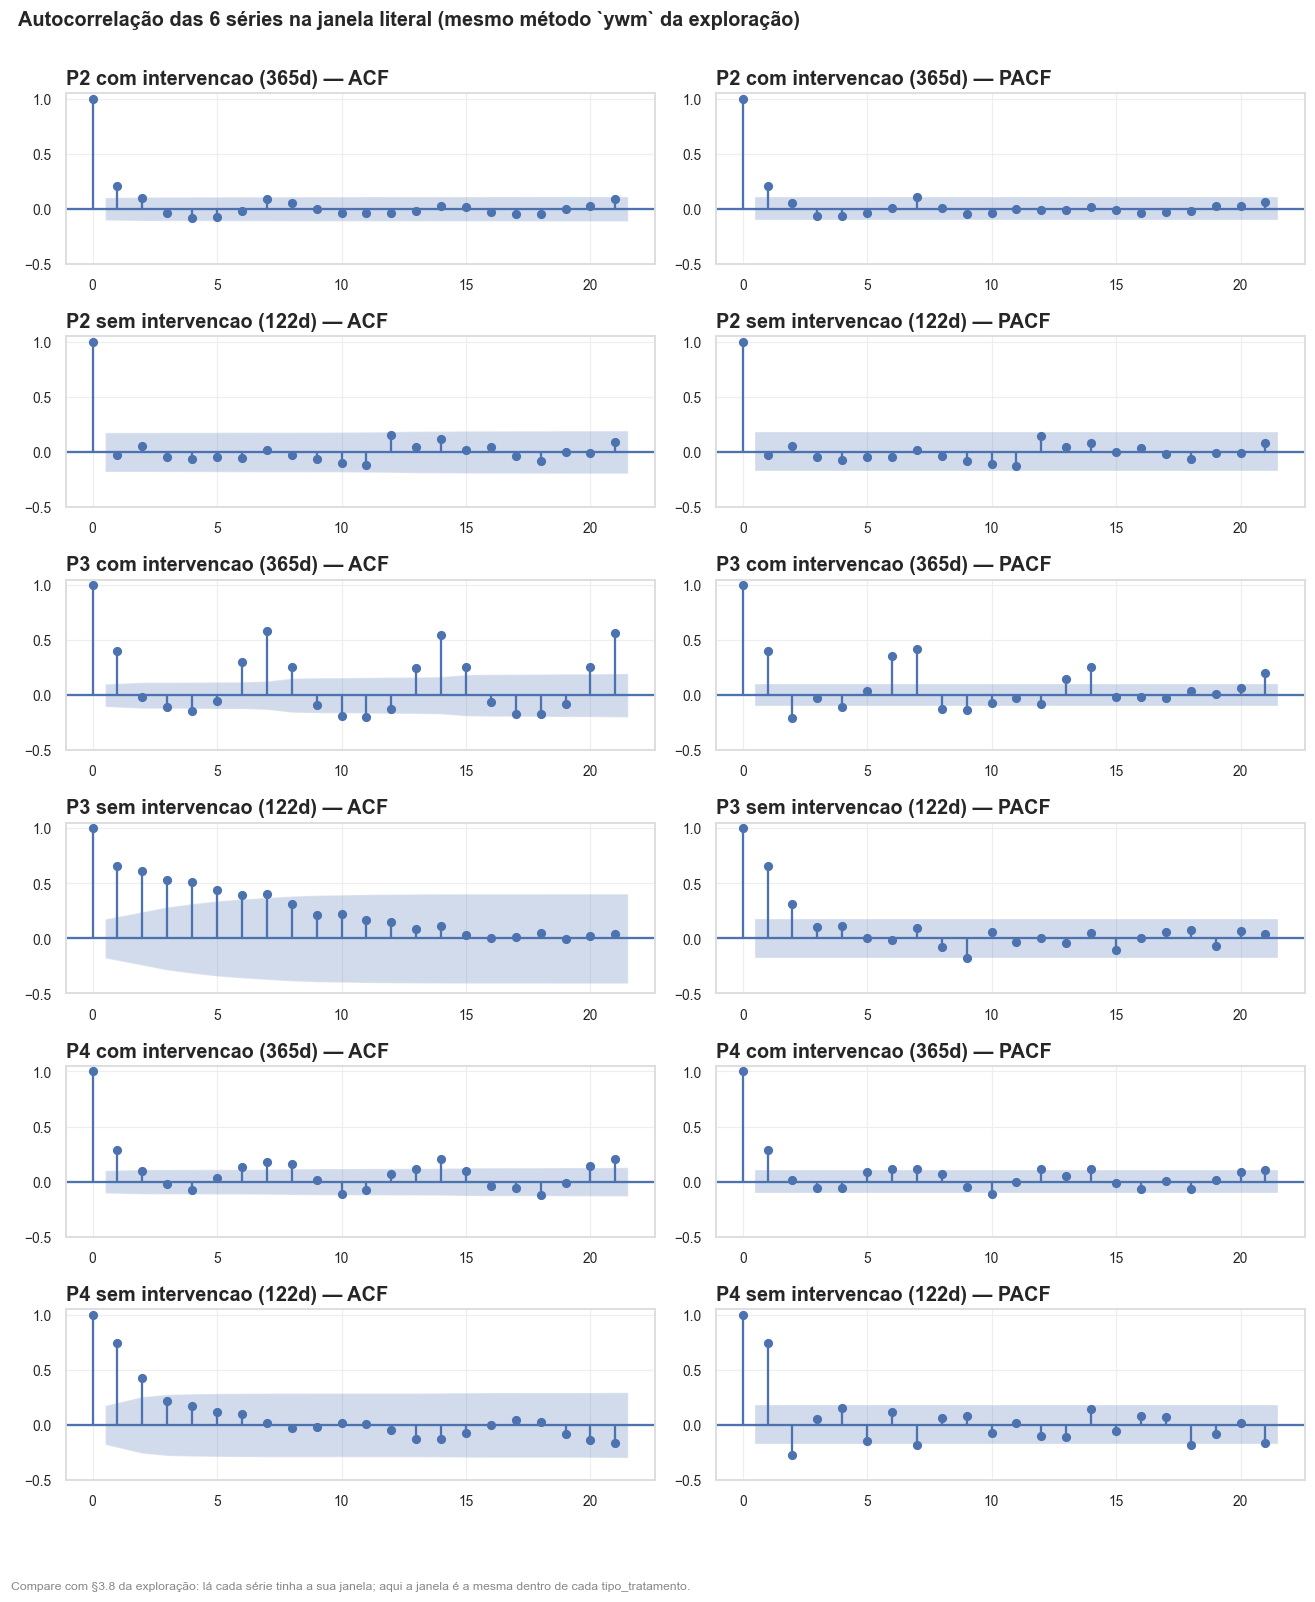

In [7]:
fig, axes = plt.subplots(len(SERIES), 2, figsize=(12, 2.3 * len(SERIES)))
for i, (p, tipo) in enumerate(SERIES):
    s = recortar(p, tipo)
    rotulo = f"P{p} {tipo.replace('_', ' ')} ({len(s)}d)"
    plot_acf(s, lags=21, ax=axes[i, 0], title=f"{rotulo} — ACF")
    plot_pacf(s, lags=21, ax=axes[i, 1], method="ywm", title=f"{rotulo} — PACF")
    for ax in axes[i]:
        ax.set_ylim(-0.5, 1.05)
fig.suptitle("Autocorrelação das 6 séries na janela literal (mesmo método `ywm` da exploração)",
             y=1.0, fontsize=13, weight="bold", x=0.01, ha="left")
finalizar(fig, "Compare com §3.8 da exploração: lá cada série tinha a sua janela; aqui a janela é "
               "a mesma dentro de cada tipo_tratamento.")

**Leitura — só o registro, sem investigar a fundo.**

| Série | O que chama atenção na janela literal |
|---|---|
| **P2 com** | Nível baixo e ruidoso, com picos isolados que dominam o RMSE. ACF decai rápido e a sazonalidade semanal é fraca. Nenhuma descontinuidade grosseira ao longo de 2025. |
| **P3 com** | Sobe de patamar no último trimestre — é a quebra fina de 25/10 já identificada na exploração, aqui **dentro** da janela por decisão de negócio. Fica registrado: o modelo treina atravessando essa mudança. |
| **P4 com** | A mais bem-comportada das seis. ACF com decaimento suave e PACF cortando cedo: estrutura autorregressiva curta, do tipo que média móvel já captura bem. |
| **P2 sem** | 122 dias, muito ruído e picos isolados grandes. Autocorrelação praticamente inexistente além do lag 1. |
| **P3 sem** | **O caso mais delicado.** Fica em torno de ~100/dia de setembro a meados de dezembro e depois sobe para a faixa dos ~450/dia nas últimas duas semanas — mudança de patamar dentro da janela, e ela cai exatamente sobre as últimas dobras de validação. |
| **P4 sem** | Nível alto (~460/dia) e oscilação larga sem tendência clara; ACF fraca. |

Dois registros importam para ler os números adiante, e nenhum vira investigação nova — ambos já
estão diagnosticados na exploração:

1. **P3 (nos dois tipos) treina atravessando mudança de patamar.** Consequência esperada: modelo
   ajustado no patamar antigo subestima o novo. É o preço declarado da regra literal de janela.
2. **As três séries `sem_intervencao` têm 122 dias.** Um modelo com ~19 features aprende pouco
   nesse volume — a §5 mostra exatamente isso acontecendo.

---
# 3. Features, validação e piso

Três coisas fecham aqui, nesta ordem, e **nenhuma célula depois desta seção cria feature nova**:
a lista de features, o esquema de validação e o piso de baselines.

## 3.1 A regra dura da recursividade

O D+7 não tem modelo próprio: é o modelo de D+1 aplicado sete vezes, realimentando a própria
previsão (§6). Isso restringe o que pode ser feature, porque no passo 3 da recursão só existe o
que é **conhecido para uma data futura** ou **recalculável a partir da previsão**:

| Origem | Entra? | Por quê |
|---|---|---|
| **Calendário** (`s_dim_calendario`) | Sim | Dia da semana, feriado e ciclos seno/cosseno são conhecidos para qualquer data futura, sem previsão nenhuma |
| **Lags e janelas móveis do alvo** (`abertos`) | Sim | No passo k, o valor real é substituído pela previsão do passo k−1 e o lag é recalculado com a mesma fórmula |
| **Exógenas do fato** (`ics_distintos`, `times_distintos`, `descricoes_distintas`, `backlog`, `fechados*`, `duracao_*`, `taxa_monitoramento`, outra prioridade) | **Não** | Nenhuma é conhecida em D+3 sem ser ela própria prevista |

**A decisão sobre as exógenas, explícita.** A regra permite manter uma exógena se houver forma
defensável de "congelá-la" — média histórica fixa, por exemplo. Não há, e a razão é a mesma para
todas: são medidas **do mesmo dia** que o alvo e se movem **junto** com ele. Congelar
`ics_distintos` na média histórica não é conservador, é injetar no passo futuro a informação de
que o dia será médio — que é justamente o que se quer prever. Um valor constante também não
resolve: coluna constante não carrega sinal. A lista final tem, portanto, **zero features
exógeno-congeladas**, e a coluna `origem` do dicionário abaixo registra isso.

Vale dizer o que a restrição custa: a exploração mostrou que a carga se concentra em poucos ICs e
templates, e nada disso entra no modelo. A concentração continua sendo um bom **descritor** da
série — só não é utilizável como **preditor** num desenho recursivo.

**Convenção de alinhamento.** Cada linha da matriz é indexada pela **data-alvo** `D`: as features
resumem o histórico até `D−1` e o alvo é `abertos[D]`. A origem da previsão é, portanto, `D−1`.
Escrito assim, `lag_1` é exatamente o baseline ingênuo, e a mesma matriz serve ao passo recursivo
sem nenhum reajuste de índice.

In [8]:
FEATURES_CALENDARIO = [
    "dia_semana", "fim_de_semana", "dia_util", "feriado", "vespera_feriado", "pos_feriado",
    "sen_semana", "cos_semana", "sen_ano", "cos_ano", "dia_mes",
]
FEATURES_ALVO = [f"lag_{k}" for k in LAGS_ALVO] + [f"media_{j}d" for j in JANELAS_ALVO]
FEATURES_PRIORIDADE = [f"prio_{p}" for p in PRIORIDADES]   # só existem no modelo pooled (§4)

FEATURES = FEATURES_CALENDARIO + FEATURES_ALVO

ORIGEM_FEATURE = {
    **{f: "calendário" for f in FEATURES_CALENDARIO},
    **{f: "lag-rolling do alvo" for f in FEATURES_ALVO},
    **{f: "dimensão da série" for f in FEATURES_PRIORIDADE},
}


def features_do_alvo(historico):
    """
    Lags e janelas móveis de `abertos`, indexados pela DATA-ALVO.

    Tudo passa por `shift`: a linha da data D só enxerga valores até D-1. É a mesma fórmula usada
    no passo recursivo da §6 — reaproveitar esta função é o que garante que treino e recursão
    calculem a feature do mesmo jeito.
    """
    colunas = {f"lag_{k}": historico.shift(k) for k in LAGS_ALVO}
    colunas.update({f"media_{j}d": historico.shift(1).rolling(j).mean() for j in JANELAS_ALVO})
    return pd.DataFrame(colunas, index=historico.index)


CALENDARIO = dim_calendario[["data"] + FEATURES_CALENDARIO].copy()


def historico_completo(prioridade, tipo):
    """Série `abertos` inteira da silver, sem recorte de janela."""
    return (
        fato_prioridade
        .query("prioridade == @prioridade and tipo_tratamento == @tipo")
        .sort_values("data").set_index("data")["abertos"].astype(float)
    )


def montar_matriz(prioridade, tipo):
    """
    Matriz de treino de uma série: features (calendário + alvo) e `y = abertos[D]`.

    Os lags são calculados sobre o histórico INTEIRO da silver e só depois a janela do §1.4 é
    recortada. Usar o passado imediatamente anterior à janela apenas para preencher `media_30d`
    evita 30 linhas nulas no começo — e não é vazamento: é passado, não futuro.
    """
    historico = historico_completo(prioridade, tipo)
    matriz = (
        features_do_alvo(historico)
        .join(historico.rename("y"))
        .reset_index()
        .merge(CALENDARIO, on="data", how="left")
    )
    ini, fim = JANELA_TREINO_TESTE[tipo]
    matriz = matriz.query("@ini <= data <= @fim").reset_index(drop=True)
    matriz["prioridade"] = prioridade
    matriz["tipo_tratamento"] = tipo
    for p in PRIORIDADES:
        matriz[f"prio_{p}"] = int(prioridade == p)
    return matriz


MATRIZES = {(p, t): montar_matriz(p, t) for p, t in SERIES}
PAINEL = {
    tipo: pd.concat([MATRIZES[(p, tipo)] for p in PRIORIDADES], ignore_index=True)
    for tipo in TIPOS_TRATAMENTO
}

for chave, m in MATRIZES.items():
    nulos = int(m[FEATURES].isna().sum().sum())
    assert nulos == 0, f"{chave}: {nulos} nulos nas features"

print(f"{len(FEATURES)} features fechadas — nenhuma célula adiante cria feature nova.\n")
print(
    pd.DataFrame({"feature": FEATURES, "origem": [ORIGEM_FEATURE[f] for f in FEATURES]})
    .to_string(index=False)
)
print(f"\n+ {len(FEATURES_PRIORIDADE)} indicadoras de prioridade, exclusivas do modelo pooled: "
      f"{', '.join(FEATURES_PRIORIDADE)}")
print("\nMatrizes: " + " | ".join(f"P{p} {t}: {m.shape[0]}x{len(FEATURES)}"
                                 for (p, t), m in MATRIZES.items()))

19 features fechadas — nenhuma célula adiante cria feature nova.

        feature              origem
     dia_semana          calendário
  fim_de_semana          calendário
       dia_util          calendário
        feriado          calendário
vespera_feriado          calendário
    pos_feriado          calendário
     sen_semana          calendário
     cos_semana          calendário
        sen_ano          calendário
        cos_ano          calendário
        dia_mes          calendário
          lag_1 lag-rolling do alvo
          lag_2 lag-rolling do alvo
          lag_3 lag-rolling do alvo
          lag_7 lag-rolling do alvo
         lag_14 lag-rolling do alvo
       media_7d lag-rolling do alvo
      media_14d lag-rolling do alvo
      media_30d lag-rolling do alvo

+ 3 indicadoras de prioridade, exclusivas do modelo pooled: prio_2, prio_3, prio_4

Matrizes: P2 com_intervencao: 365x19 | P2 sem_intervencao: 122x19 | P3 com_intervencao: 365x19 | P3 sem_intervencao: 122x19 | P4 

## 3.2 Validação temporal

`TimeSeriesSplit` com `gap=1` — o gap é igual ao horizonte do modelo-base, então o último dia de
treino nunca é o dia que gera a feature da primeira linha de teste. Sem `shuffle`: a ordem do
tempo é a única ordem que existe aqui.

Duas escolhas de desenho merecem registro:

- **`test_size` fixo em vez de dobras crescentes iguais.** Com o `TimeSeriesSplit` padrão, quatro
  dobras em 122 dias fariam a primeira treinar com ~24 linhas — um modelo com 19 features ajustado
  em 24 pontos não mede nada além de ruído. Fixando o tamanho do teste, o treino cresce de 60 a
  105 dias em `sem_intervencao`, e de 123 a 323 em `com_intervencao`.
- **Todas as séries do mesmo `tipo_tratamento` compartilham as mesmas datas de dobra.** As dobras
  são construídas sobre o eixo de datas, não sobre linhas. É isso que torna o modelo pooled e os
  individuais comparáveis linha a linha na §4: mesmo conjunto de teste, mesmo denominador.

In [9]:
def dobras_temporais(tipo):
    """Lista de (datas_treino, datas_teste) — recortes sobre o eixo de datas, não sobre linhas."""
    cfg = VALIDACAO[tipo]
    datas = np.sort(PAINEL[tipo]["data"].unique())
    divisor = TimeSeriesSplit(
        n_splits=cfg["n_dobras"], gap=GAP_VALIDACAO, test_size=cfg["tamanho_teste"]
    )
    return [(datas[i_tr], datas[i_te]) for i_tr, i_te in divisor.split(datas)]


DOBRAS = {tipo: dobras_temporais(tipo) for tipo in TIPOS_TRATAMENTO}
DATAS_TESTE = {
    tipo: np.sort(np.concatenate([te for _, te in DOBRAS[tipo]]))
    for tipo in TIPOS_TRATAMENTO
}

esquema = []
for tipo, dobras in DOBRAS.items():
    for i, (tr, te) in enumerate(dobras, start=1):
        esquema.append({
            "tipo_tratamento": tipo, "dobra": i,
            "treino_inicio": pd.Timestamp(tr.min()).date(),
            "treino_fim": pd.Timestamp(tr.max()).date(), "n_treino_dias": len(tr),
            "teste_inicio": pd.Timestamp(te.min()).date(),
            "teste_fim": pd.Timestamp(te.max()).date(), "n_teste_dias": len(te),
        })
ESQUEMA_VALIDACAO = pd.DataFrame(esquema)
print(ESQUEMA_VALIDACAO.to_string(index=False))

for tipo, dobras in DOBRAS.items():
    todas = np.concatenate([te for _, te in dobras])
    assert len(todas) == len(np.unique(todas)), f"{tipo}: dobras de teste se sobrepõem"
    for tr, te in dobras:
        assert not (set(te) & set(tr)), f"{tipo}: data de teste aparece no treino"
        assert te.min() > tr.max(), f"{tipo}: teste começa antes do fim do treino"

print("\nAceite Item 3 OK — sem overlap de teste entre dobras, sem data de teste dentro do treino.")
for tipo in TIPOS_TRATAMENTO:
    d = DATAS_TESTE[tipo]
    print(f"  {tipo:<16}: {len(d)} dias avaliados por série "
          f"({pd.Timestamp(d.min()):%d/%m/%Y} a {pd.Timestamp(d.max()):%d/%m/%Y})")

tipo_tratamento  dobra treino_inicio treino_fim  n_treino_dias teste_inicio  teste_fim  n_teste_dias
com_intervencao      1    2025-01-01 2025-05-04            124   2025-05-06 2025-06-14            40
com_intervencao      2    2025-01-01 2025-06-13            164   2025-06-15 2025-07-24            40
com_intervencao      3    2025-01-01 2025-07-23            204   2025-07-25 2025-09-02            40
com_intervencao      4    2025-01-01 2025-09-01            244   2025-09-03 2025-10-12            40
com_intervencao      5    2025-01-01 2025-10-11            284   2025-10-13 2025-11-21            40
com_intervencao      6    2025-01-01 2025-11-20            324   2025-11-22 2025-12-31            40
sem_intervencao      1    2025-09-01 2025-10-31             61   2025-11-02 2025-11-16            15
sem_intervencao      2    2025-09-01 2025-11-15             76   2025-11-17 2025-12-01            15
sem_intervencao      3    2025-09-01 2025-11-30             91   2025-12-02 2025-12-16     

## 3.3 Baselines — o piso

São os mesmos quatro baselines já formalizados na exploração; aqui só a fórmula é recalculada,
dentro das novas janelas. Escritos em função da origem `O = D − h`, valem para os dois horizontes:

| Baseline | Previsão para o dia `D`, feita na origem `O` |
|---|---|
| ingênuo | `abertos[O]` |
| sazonal lag-7 | `abertos[D−7]` — mesmo dia da semana anterior, conhecido em `O` para h ≤ 7 |
| MM7 | média dos 7 dias até `O` |
| MM30 | média dos 30 dias até `O` |

**Os baselines são medidos exatamente nas mesmas datas que os modelos** — só nos dias de teste
das dobras. Comparar um baseline calculado na janela inteira com um modelo avaliado apenas
out-of-fold seria dar ao piso um conjunto mais fácil.

In [10]:
NOMES_BASELINE = ["ingênuo", "sazonal lag-7", "MM7", "MM30"]


def baselines_do_horizonte(historico, passos):
    """Previsão dos 4 baselines para cada data-alvo D, feita na origem O = D - passos."""
    return pd.DataFrame({
        "ingênuo": historico.shift(passos),
        "sazonal lag-7": historico.shift(7),
        "MM7": historico.shift(passos).rolling(7).mean(),
        "MM30": historico.shift(passos).rolling(30).mean(),
    }, index=historico.index)


def metricas(y, previsto):
    """MAE, RMSE e MAPE. O MAPE usa max(y, 1) no denominador, como na exploração."""
    y, previsto = np.asarray(y, dtype=float), np.asarray(previsto, dtype=float)
    erro = y - previsto
    return {
        "mae": float(np.abs(erro).mean()),
        "rmse": float(np.sqrt((erro ** 2).mean())),
        "mape": float(np.mean(np.abs(erro) / np.maximum(y, 1)) * 100),
    }


PASSOS_DO_HORIZONTE = {"D+1": 1, "D+7": 7}

linhas = []
for p, tipo in SERIES:
    historico = historico_completo(p, tipo)
    real = historico.loc[DATAS_TESTE[tipo]]
    for horizonte, passos in PASSOS_DO_HORIZONTE.items():
        previsoes = baselines_do_horizonte(historico, passos).loc[DATAS_TESTE[tipo]]
        for nome in NOMES_BASELINE:
            linhas.append({
                "prioridade": p, "tipo_tratamento": tipo, "horizonte": horizonte,
                "baseline": nome, "n": len(real), **metricas(real, previsoes[nome]),
            })
BASELINES = pd.DataFrame(linhas)

MELHOR_BASELINE = (
    BASELINES.loc[BASELINES.groupby(["prioridade", "tipo_tratamento", "horizonte"])["mae"].idxmin()]
    .set_index(["prioridade", "tipo_tratamento", "horizonte"])
)

print("PISO — nenhum modelo entra na tabela final sem superar o MAE da sua linha.\n")
print(
    MELHOR_BASELINE.reset_index()
    [["prioridade", "tipo_tratamento", "horizonte", "baseline", "mae", "rmse", "mape"]]
    .round(2).to_string(index=False)
)
print("\nTodos os baselines (MAE), por horizonte:\n")
print(
    BASELINES.pivot_table(index=["tipo_tratamento", "prioridade", "baseline"],
                          columns="horizonte", values="mae").round(2).to_string()
)

PISO — nenhum modelo entra na tabela final sem superar o MAE da sua linha.

 prioridade tipo_tratamento horizonte      baseline   mae   rmse   mape
          2 com_intervencao       D+1          MM30 17.55  35.48  88.45
          2 com_intervencao       D+7          MM30 17.52  35.45  88.31
          2 sem_intervencao       D+1          MM30 36.54  85.78 113.36
          2 sem_intervencao       D+7          MM30 36.07  85.53 114.63
          3 com_intervencao       D+1 sazonal lag-7 17.29  23.06  53.86
          3 com_intervencao       D+7       ingênuo 17.29  23.06  53.86
          3 sem_intervencao       D+1       ingênuo 51.25  64.29  31.78
          3 sem_intervencao       D+7       ingênuo 81.55 109.78  50.74
          4 com_intervencao       D+1           MM7  8.43  11.82  60.85
          4 com_intervencao       D+7          MM30  8.69  11.97  88.21
          4 sem_intervencao       D+1       ingênuo 51.82  67.29  10.92
          4 sem_intervencao       D+7       ingênuo 79.25 10

**Leitura do piso.** O melhor baseline muda por série, e isso já antecipa a estrutura de cada uma:
onde a **MM30 ganha**, a série é ruído em torno de um nível estável e a melhor aposta é a média
longa; onde o **ingênuo ganha**, a série tem persistência forte e patamar móvel — o valor de
ontem carrega mais informação que qualquer média. As do segundo tipo são as mais difíceis de
bater com modelo aprendido: o ingênuo acompanha a mudança de patamar de graça, enquanto o modelo
precisa aprendê-la a partir de dados que ainda não a contêm.

**Uma coincidência esperada na coluna D+7.** Em h = 7, o ingênuo (`abertos[O]`, com `O = D − 7`) e
o sazonal lag-7 (`abertos[D − 7]`) são a **mesma previsão** — daí as duas linhas idênticas na
tabela. Não é erro de cálculo: é a definição dos dois baselines convergindo exatamente nesse
horizonte. Quando eles empatam no menor MAE, o desempate cai no primeiro da lista, e o rótulo
registrado é `ingênuo`.

---
# 4. Objetivo 1 — vale agrupar as prioridades num modelo só?

A pergunta é operacional antes de ser estatística: manter **um** modelo por `tipo_tratamento`,
com a prioridade entrando como variável, ou **três**, um por prioridade? Um modelo agrupado tem
mais linhas de treino (3× a janela) e compartilha o que é comum às três séries — tipicamente o
efeito de calendário. Modelos individuais capturam nível e dinâmica próprios de cada prioridade,
ao custo de treinar cada um com um terço dos dados.

O experimento roda os **três candidatos** da §5 nos dois escopos, sobre as mesmas dobras e as
mesmas datas de teste. A comparação é sempre **por prioridade**: o que interessa é se a série P3
é melhor prevista por um modelo que também viu P2 e P4.

In [11]:
def fabricar_modelos(tipo):
    """
    Devolve estimadores NOVOS a cada chamada — modelo ajustado numa dobra nunca é reaproveitado
    na seguinte.

    A parametrização muda entre os dois grupos de comportamento, e a razão é o volume: 365 dias
    contra 122. Em `sem_intervencao` tudo é encolhido — mais regularização no GLM e no MLP,
    árvore mais rasa e menos estimadores no boosting. É a instrução de preferir o parcimonioso
    quando a série é curta, aplicada literalmente.
    """
    if tipo == "com_intervencao":
        return {
            "GLM Poisson": Pipeline([
                ("escala", StandardScaler()),
                ("glm", PoissonRegressor(alpha=1.0, max_iter=3000)),
            ]),
            "Gradient Boosting": GradientBoostingRegressor(
                n_estimators=200, max_depth=3, learning_rate=0.05,
                subsample=0.9, random_state=SEMENTE,
            ),
            "MLP": Pipeline([
                ("escala", StandardScaler()),
                ("rede", MLPRegressor(hidden_layer_sizes=(16, 8), alpha=1.0,
                                      max_iter=3000, random_state=SEMENTE)),
            ]),
        }
    return {
        "GLM Poisson": Pipeline([
            ("escala", StandardScaler()),
            ("glm", PoissonRegressor(alpha=5.0, max_iter=3000)),
        ]),
        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=80, max_depth=2, learning_rate=0.05,
            subsample=0.8, random_state=SEMENTE,
        ),
        "MLP": Pipeline([
            ("escala", StandardScaler()),
            ("rede", MLPRegressor(hidden_layer_sizes=(8,), alpha=5.0,
                                  max_iter=5000, random_state=SEMENTE)),
        ]),
    }


NOMES_MODELO = list(fabricar_modelos("com_intervencao"))
ESCOPOS = ["pooled", "individual"]


def colunas_do_escopo(escopo):
    """No pooled a prioridade é feature; no individual ela é o próprio recorte dos dados."""
    return FEATURES + (FEATURES_PRIORIDADE if escopo == "pooled" else [])


def dados_do_escopo(tipo, escopo, prioridade=None):
    return PAINEL[tipo] if escopo == "pooled" else MATRIZES[(prioridade, tipo)]


def validar(tipo, nome_modelo, escopo):
    """
    Rolling-origin do §3.2. Devolve as previsões OUT-OF-FOLD — são elas que alimentam tanto as
    métricas quanto a tabela gold de previsões (§8), e nunca uma previsão in-sample.
    """
    colunas = colunas_do_escopo(escopo)
    previsoes = []
    for i, (datas_treino, datas_teste) in enumerate(DOBRAS[tipo], start=1):
        grupos = [None] if escopo == "pooled" else PRIORIDADES
        for prioridade in grupos:
            base = dados_do_escopo(tipo, escopo, prioridade)
            treino = base[base["data"].isin(datas_treino)]
            teste = base[base["data"].isin(datas_teste)]
            modelo = fabricar_modelos(tipo)[nome_modelo]
            modelo.fit(treino[colunas], treino["y"])
            previsoes.append(pd.DataFrame({
                "data": teste["data"].to_numpy(),
                "prioridade": teste["prioridade"].to_numpy(),
                "dobra": i,
                "n_treino": len(treino),
                "y": teste["y"].to_numpy(),
                # Contagem não é negativa: o corte em zero faz parte da definição do preditor.
                "valor_previsto": np.maximum(modelo.predict(teste[colunas]), 0),
            }))
    return pd.concat(previsoes, ignore_index=True)


PREVISOES_OOF = {}
for tipo in TIPOS_TRATAMENTO:
    for nome_modelo in NOMES_MODELO:
        for escopo in ESCOPOS:
            PREVISOES_OOF[(tipo, nome_modelo, escopo)] = validar(tipo, nome_modelo, escopo)

print(f"{len(PREVISOES_OOF)} execuções de validação concluídas "
      f"({len(TIPOS_TRATAMENTO)} tipos x {len(NOMES_MODELO)} modelos x {len(ESCOPOS)} escopos).")

12 execuções de validação concluídas (2 tipos x 3 modelos x 2 escopos).


In [12]:
linhas = []
for (tipo, nome_modelo, escopo), previsoes in PREVISOES_OOF.items():
    for p in PRIORIDADES:
        serie = previsoes.query("prioridade == @p")
        linhas.append({
            "prioridade": p, "tipo_tratamento": tipo, "horizonte": "D+1",
            "modelo": nome_modelo, "escopo": escopo,
            "n_treino": int(serie["n_treino"].mean() / (3 if escopo == "pooled" else 1)),
            "n_teste": len(serie), **metricas(serie["y"], serie["valor_previsto"]),
        })
AVALIACAO_D1 = pd.DataFrame(linhas)

comparativo = (
    AVALIACAO_D1
    .pivot_table(index=["tipo_tratamento", "prioridade", "modelo"], columns="escopo",
                 values=["mae", "rmse", "mape"])
)
comparativo = comparativo.reindex(columns=ESCOPOS, level=1)
ganho = ((comparativo[("mae", "individual")] - comparativo[("mae", "pooled")])
         / comparativo[("mae", "individual")] * 100)
comparativo[("mae", "ganho_pooled_%")] = ganho

print("Pooled vs individual — MAE, RMSE, MAPE por prioridade\n")
print(comparativo.round(2).to_string())

print("\nQuem vence, por prioridade e modelo (MAE):\n")
melhor_escopo = AVALIACAO_D1.loc[
    AVALIACAO_D1.groupby(["tipo_tratamento", "prioridade", "modelo"])["mae"].idxmin()
]
print(
    melhor_escopo[["tipo_tratamento", "prioridade", "modelo", "escopo", "mae"]]
    .round(2).to_string(index=False)
)
print("\nPlacar do pooling (nº de vitórias em 9 combinações prioridade x modelo, por tipo):\n")
placar = (
    AVALIACAO_D1
    .loc[AVALIACAO_D1.groupby(["tipo_tratamento", "prioridade", "modelo"])["mae"].idxmin()]
    .groupby(["tipo_tratamento", "escopo"]).size().rename("vitórias").reset_index()
)
print(placar.to_string(index=False))

Pooled vs individual — MAE, RMSE, MAPE por prioridade

                                                mae              mape              rmse                       mae
escopo                                       pooled individual pooled individual pooled individual ganho_pooled_%
tipo_tratamento prioridade modelo                                                                                
com_intervencao 2          GLM Poisson        15.95      16.56  69.40      74.29  34.36      34.75           3.71
                           Gradient Boosting  17.90      19.87  82.12     102.33  35.54      36.91           9.92
                           MLP                21.70      29.92 112.72     172.22  39.07      48.28          27.49
                3          GLM Poisson        16.34      16.66  75.62      66.13  20.29      21.49           1.91
                           Gradient Boosting  15.35      16.24  64.62      71.05  20.26      21.08           5.49
                           MLP   

**Conclusão do Objetivo 1 — sim para os dois tipos, por motivos diferentes.**

Contando as 9 combinações prioridade × modelo dentro de cada tipo, o pooled ganha **6 de 9** em
`com_intervencao` e **8 de 9** em `sem_intervencao`. A resposta é a mesma nos dois casos, mas o
tamanho do efeito não é, e a diferença diz mais que o placar:

| | `com_intervencao` (365 dias) | `sem_intervencao` (122 dias) |
|---|---|---|
| Vitórias do pooled | 6 / 9 | 8 / 9 |
| Ganho típico de MAE | 2 % a 10 % | 9 % a 61 % |
| Onde o individual ainda ganha | P4 com GLM (−4,5 %), P3 com MLP | P3 com MLP |

**Em `com_intervencao` o pooling é uma melhora modesta.** Com 365 dias por série, cada modelo
individual já tem dados suficientes para estimar os próprios coeficientes; o que o pooled
acrescenta é estabilidade nas features compartilhadas — o efeito de dia da semana e de dia útil é
o mesmo nas três prioridades e estimá-lo com 3× mais linhas reduz variância. Por isso o ganho
aparece principalmente nos modelos com mais parâmetros para estimar (MLP: +27 %) e quase some no
GLM de P4, a série mais bem-comportada, onde o individual chega a vencer.

**Em `sem_intervencao` o pooling é o que torna o modelo viável.** 122 dias contra 19 features é
pouco demais: o GLM individual de P2 chega a MAE 84,2 contra 38,9 do pooled — uma diferença que
não é sobre a estrutura da série, é sobre não haver dados. Triplicar as linhas de treino não
resolve o problema dessas séries (a §5 mostra que nenhuma delas supera o piso), mas remove a
parte do erro que era puramente falta de amostra.

**A ressalva honesta.** Pooling aqui significa somar séries de níveis muito diferentes — em
`sem_intervencao`, P2 gira em ~51/dia e P4 em ~460/dia. O modelo absorve isso pelas indicadoras
de prioridade, o que funciona para deslocar o nível, mas não permite que cada série tenha
dinâmica própria. É uma troca: menos variância, mais viés. Nos números acima a troca compensou em
14 das 18 combinações.

---
# 5. Objetivos 2 e 3 — os três candidatos e a escolha

Os dois grupos de comportamento vêm da exploração e não são reabertos aqui:

- **`com_intervencao`** — série densa, 365 dias, sazonalidade semanal mais marcada;
- **`sem_intervencao`** — série recente, 122 dias, volume concentrado em poucos templates/ICs
  (achado da §3 da exploração, citado aqui só como justificativa).

Os mesmos três candidatos rodam nos dois grupos, para que a comparação seja pareada. O que muda
entre os grupos é a **parametrização**, não a família:

| Candidato | Por que cabe em `com_intervencao` | Por que cabe em `sem_intervencao` |
|---|---|---|
| **GLM Poisson** | Alvo é contagem e o link log respeita o suporte não negativo; com 365 dias os coeficientes são estimados com folga e ficam interpretáveis | É o mais parcimonioso dos três — com 122 dias e `alpha` alto, é o que menos tem a perder por falta de dados |
| **Gradient Boosting** | Captura interação entre calendário e lag (o efeito de domingo depende do nível da semana), que o GLM só pega se a interação for escrita à mão | A concentração da carga em poucos templates produz patamares e degraus; árvore modela degrau melhor que reta — **mas não extrapola acima do que viu no treino**, e essa limitação vai aparecer nos números |
| **MLP (1–2 camadas)** | Obrigatório pelo objetivo 3; com 365 linhas, `(16, 8)` já é o teto razoável | Reduzido a `(8,)` com regularização forte: uma rede maior em 122 linhas decora o treino |

**Regra de escolha, aplicada na célula abaixo, nesta ordem:**

1. descartar quem não supera o **melhor baseline** da própria série (§3.3) — regra do piso;
2. entre os que sobram, o **menor MAE** na validação;
3. se a diferença de MAE for menor que a tolerância de empate técnico (2 %), escolher o **mais
   simples**: GLM antes de Gradient Boosting antes de MLP, e pooled antes de individual (um
   modelo em produção pesa menos que três).

In [13]:
AVALIACAO_D1 = AVALIACAO_D1.merge(
    MELHOR_BASELINE.reset_index()[["prioridade", "tipo_tratamento", "horizonte",
                                   "baseline", "mae"]]
    .rename(columns={"baseline": "nome_melhor_baseline", "mae": "melhor_baseline"}),
    on=["prioridade", "tipo_tratamento", "horizonte"], how="left",
)
AVALIACAO_D1["supera_baseline"] = AVALIACAO_D1["mae"] < AVALIACAO_D1["melhor_baseline"]
AVALIACAO_D1["ganho_sobre_piso_%"] = (
    (1 - AVALIACAO_D1["mae"] / AVALIACAO_D1["melhor_baseline"]) * 100
)

print("Modelo x série x escopo — D+1, validação out-of-fold\n")
print(
    AVALIACAO_D1.sort_values(["tipo_tratamento", "prioridade", "mae"])
    [["tipo_tratamento", "prioridade", "modelo", "escopo", "mae", "rmse", "mape",
      "nome_melhor_baseline", "melhor_baseline", "supera_baseline", "ganho_sobre_piso_%"]]
    .round(2).to_string(index=False)
)

Modelo x série x escopo — D+1, validação out-of-fold

tipo_tratamento  prioridade            modelo     escopo    mae   rmse   mape nome_melhor_baseline  melhor_baseline  supera_baseline  ganho_sobre_piso_%
com_intervencao           2       GLM Poisson     pooled  15.95  34.36  69.40                 MM30            17.55             True                9.13
com_intervencao           2       GLM Poisson individual  16.56  34.75  74.29                 MM30            17.55             True                5.64
com_intervencao           2 Gradient Boosting     pooled  17.90  35.54  82.12                 MM30            17.55            False               -1.97
com_intervencao           2 Gradient Boosting individual  19.87  36.91 102.33                 MM30            17.55            False              -13.19
com_intervencao           2               MLP     pooled  21.70  39.07 112.72                 MM30            17.55            False              -23.62
com_intervencao           2 

In [14]:
def escolher_vencedor(prioridade, tipo):
    """
    Aplica a regra do §5: piso -> menor MAE -> empate técnico resolvido pela simplicidade.

    Quando nenhum candidato supera o piso, o vencedor é o próprio baseline. Isso não é uma
    brecha na regra do Item 4 — é a consequência dela: o handoff manda descartar quem não bate
    o piso, e uma série sem candidato aprovado continua precisando de uma previsão para entregar
    na camada gold. O que se entrega, então, é o piso, marcado como tal.
    """
    candidatos = AVALIACAO_D1.query(
        "prioridade == @prioridade and tipo_tratamento == @tipo and supera_baseline"
    )
    piso = MELHOR_BASELINE.loc[(prioridade, tipo, "D+1")]

    if candidatos.empty:
        return {
            "modelo": f"Baseline {piso['baseline']}", "escopo": "baseline",
            "mae": float(piso["mae"]), "e_baseline": True,
            "razao": "nenhum candidato superou o piso — entrega-se o melhor baseline da série",
        }

    melhor = candidatos["mae"].min()
    empatados = candidatos[candidatos["mae"] <= melhor * (1 + TOLERANCIA_EMPATE)]
    escolhido = empatados.sort_values(
        by=["modelo", "escopo"],
        key=lambda col: col.map(ORDEM_SIMPLICIDADE if col.name == "modelo" else ORDEM_ESCOPO),
    ).iloc[0]
    por_simplicidade = len(empatados) > 1 and escolhido["mae"] > melhor
    return {
        "modelo": escolhido["modelo"], "escopo": escolhido["escopo"],
        "mae": float(escolhido["mae"]), "e_baseline": False,
        "razao": ("empate técnico (< 2 % de MAE) resolvido pelo modelo mais simples"
                  if por_simplicidade else "menor MAE na validação, com folga sobre os demais"),
    }


VENCEDORES = {(p, tipo): escolher_vencedor(p, tipo) for p, tipo in SERIES}

print("Vencedor de D+1 por série\n")
print(
    pd.DataFrame([{"prioridade": p, "tipo_tratamento": t, **v} for (p, t), v in VENCEDORES.items()])
    [["prioridade", "tipo_tratamento", "modelo", "escopo", "mae", "razao"]]
    .round(2).to_string(index=False)
)

Vencedor de D+1 por série

 prioridade tipo_tratamento            modelo     escopo   mae                                                                   razao
          2 com_intervencao       GLM Poisson     pooled 15.95                       menor MAE na validação, com folga sobre os demais
          2 sem_intervencao     Baseline MM30   baseline 36.54 nenhum candidato superou o piso — entrega-se o melhor baseline da série
          3 com_intervencao Gradient Boosting     pooled 15.35                       menor MAE na validação, com folga sobre os demais
          3 sem_intervencao  Baseline ingênuo   baseline 51.25 nenhum candidato superou o piso — entrega-se o melhor baseline da série
          4 com_intervencao       GLM Poisson individual  7.56                       menor MAE na validação, com folga sobre os demais
          4 sem_intervencao  Baseline ingênuo   baseline 51.82 nenhum candidato superou o piso — entrega-se o melhor baseline da série


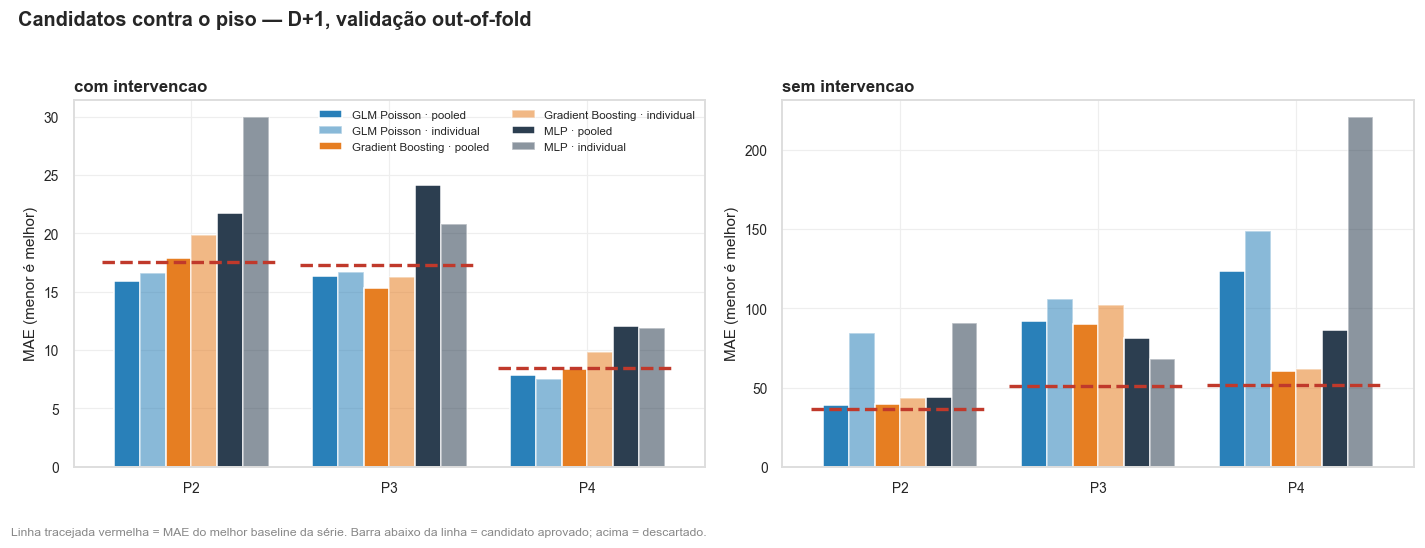

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
for ax, tipo in zip(axes, TIPOS_TRATAMENTO):
    sub = AVALIACAO_D1.query("tipo_tratamento == @tipo")
    largura = 0.13
    posicoes = np.arange(len(PRIORIDADES))
    for k, (nome_modelo, escopo) in enumerate(
        [(m, e) for m in NOMES_MODELO for e in ESCOPOS]
    ):
        v = [sub.query("prioridade == @p and modelo == @nome_modelo and escopo == @escopo")
             ["mae"].iloc[0] for p in PRIORIDADES]
        ax.bar(posicoes + (k - 2.5) * largura, v, largura,
               label=f"{nome_modelo} · {escopo}",
               alpha=1.0 if escopo == "pooled" else 0.55,
               color=[PALETA["destaque"], PALETA["p3"], PALETA["total"]][k // 2])
    piso = [MELHOR_BASELINE.loc[(p, tipo, "D+1"), "mae"] for p in PRIORIDADES]
    for x, valor in zip(posicoes, piso):
        ax.hlines(valor, x - 0.45, x + 0.45, color=PALETA["p2"], lw=2.2, ls="--")
    ax.set_xticks(posicoes, [f"P{p}" for p in PRIORIDADES])
    ax.set_title(f"{tipo.replace('_', ' ')}", fontsize=11)
    ax.set_ylabel("MAE (menor é melhor)")
axes[0].legend(fontsize=7.5, ncol=2)
fig.suptitle("Candidatos contra o piso — D+1, validação out-of-fold",
             y=1.02, fontsize=13, weight="bold", x=0.01, ha="left")
finalizar(fig, "Linha tracejada vermelha = MAE do melhor baseline da série. Barra abaixo da "
               "linha = candidato aprovado; acima = descartado.")

**Objetivos 2 e 3 — o resultado se divide exatamente pelos dois grupos de comportamento.**

| Série | Vencedor | MAE | Piso | Ganho | Razão da escolha |
|---|---|---|---|---|---|
| P2 com | **GLM Poisson · pooled** | 15,95 | 17,55 (MM30) | **+9,1 %** | menor MAE, com folga (2º lugar: 16,56) |
| P3 com | **Gradient Boosting · pooled** | 15,35 | 17,29 (sazonal) | **+11,2 %** | menor MAE, com folga (2º: 16,24) |
| P4 com | **GLM Poisson · individual** | 7,56 | 8,43 (MM7) | **+10,3 %** | menor MAE, com folga (2º: 7,90) |
| P2 sem | Baseline MM30 | 36,54 | 36,54 | — | nenhum candidato superou o piso |
| P3 sem | Baseline ingênuo | 51,25 | 51,25 | — | nenhum candidato superou o piso |
| P4 sem | Baseline ingênuo | 51,82 | 51,82 | — | nenhum candidato superou o piso |

Nenhuma escolha precisou do desempate por simplicidade: nas três séries com vencedor, a diferença
para o segundo colocado passou dos 2 % de tolerância. Ainda assim, vale notar que o critério de
simplicidade já estava embutido no resultado — em duas das três, o vencedor é o GLM, o mais
simples e o mais interpretável dos candidatos.

**Nas três séries `com_intervencao`, os modelos batem o piso em ~10 %.** É um ganho real e
consistente, mas convém dimensioná-lo: o piso já era forte, e ~10 % de MAE é a diferença entre
errar 17,5 e errar 15,9 incidentes por dia numa série que gira em 25/dia. Serve para planejar
capacidade; não serve para prometer previsão fina.

**Nas três séries `sem_intervencao`, nenhum dos três candidatos supera o piso** — e o padrão do
erro diz por quê. O melhor baseline de P3 e P4 sem é o **ingênuo**, isto é, a série tem
persistência forte e patamar móvel. É a pior combinação possível para um modelo treinado numa
janela de 122 dias que atravessa uma mudança de patamar em dezembro (registrada na §2): o
ingênuo acompanha o novo nível sem custo nenhum, enquanto o modelo teria que aprendê-lo a partir
de dados que só contêm o nível antigo. O Gradient Boosting é o caso mais nítido — árvore não
extrapola acima do máximo visto no treino, então o teto da previsão fica preso ao patamar de
novembro.

Duas leituras se seguem, e as duas são resultado, não fracasso:

1. **A regra literal de janela cobra o preço aqui.** A exploração já havia apontado que o
   breakpoint real dessas séries é 31/08–01/09 e que P3 tem quebra fina; a decisão de negócio foi
   ignorar essas quebras para manter a regra simples. Estas três linhas são o custo dessa decisão,
   agora quantificado.
2. **O que se entrega para essas séries é o baseline, marcado como tal.** A regra do Item 4 manda
   descartar candidato que não supera o piso, e a operação continua precisando de um número. O
   `escopo = "baseline"` na tabela gold torna isso explícito para quem consumir a camada — não é
   um modelo aprendido se passando por um.

---
# 6. D+7 por recursão

Um único modelo — o vencedor de D+1 — aplicado sete vezes. A previsão do passo `k` entra no
histórico e é dela que saem os lags do passo `k+1`. Como a mesma `features_do_alvo()` da §3.1 é
usada nos dois lugares, não existe a possibilidade de treino e recursão calcularem `media_7d` de
formas diferentes.

**Como o D+7 é avaliado sem vazar.** Uma previsão de sete passos feita na origem `O` só é
legítima se o modelo tiver sido treinado apenas com dados até `O`. Numa dobra cujo treino termina
em `fim_treino`, isso elimina as primeiras datas-alvo do teste — as que teriam origem *dentro* do
treino. Restam as datas `D` com `D − 7 ≥ fim_treino`, e são só essas que entram no erro de D+7.
É por isso que o `n` de D+7 é menor que o de D+1: preferimos perder linhas a relaxar a regra.

Para as séries cujo vencedor é um baseline, o D+7 é o próprio baseline no horizonte 7 (§3.3), com
a mesma fórmula e as mesmas datas — não há recursão de modelo a fazer.

In [16]:
CALENDARIO_INDEXADO = CALENDARIO.set_index("data")


def prever_recursivo(modelo, historico, origem, prioridade, escopo, passos=PASSO_MAXIMO):
    """
    Aplica o modelo de D+1 `passos` vezes, realimentando a própria previsão.

    `historico` precisa conter os valores REAIS até `origem` — nada depois. A cada passo o dia
    previsto é anexado à série e as features são recalculadas pela mesma função do treino.
    """
    colunas = colunas_do_escopo(escopo)
    # 60 dias bastam: a janela móvel mais longa é de 30 dias e o maior lag é 14.
    serie = historico.loc[:origem].tail(60).copy()
    previsto_por_passo = {}
    for k in range(1, passos + 1):
        alvo = pd.Timestamp(origem) + pd.Timedelta(days=k)
        serie.loc[alvo] = np.nan
        linha = features_do_alvo(serie).loc[[alvo]].join(CALENDARIO_INDEXADO.loc[[alvo]])
        for p in PRIORIDADES:
            linha[f"prio_{p}"] = int(prioridade == p)
        valor = float(np.maximum(modelo.predict(linha[colunas])[0], 0))
        serie.loc[alvo] = valor          # a previsão vira histórico do próximo passo
        previsto_por_passo[k] = valor
    return previsto_por_passo


def recursao_out_of_fold(prioridade, tipo, nome_modelo, escopo, passos=PASSO_MAXIMO):
    """Recursão de `passos` dias em cada dobra, só nas origens que não vazam treino."""
    historico = historico_completo(prioridade, tipo)
    colunas = colunas_do_escopo(escopo)
    linhas = []
    for i, (datas_treino, datas_teste) in enumerate(DOBRAS[tipo], start=1):
        base = dados_do_escopo(tipo, escopo, prioridade)
        treino = base[base["data"].isin(datas_treino)]
        modelo = fabricar_modelos(tipo)[nome_modelo]
        modelo.fit(treino[colunas], treino["y"])

        fim_treino = pd.Timestamp(datas_treino.max())
        for alvo in map(pd.Timestamp, datas_teste):
            origem = alvo - pd.Timedelta(days=passos)
            if origem < fim_treino:      # origem dentro do treino => o modelo veria o futuro
                continue
            caminho = prever_recursivo(modelo, historico, origem, prioridade, escopo, passos)
            for k, valor in caminho.items():
                data_k = origem + pd.Timedelta(days=k)
                linhas.append({
                    "data": data_k, "prioridade": prioridade, "tipo_tratamento": tipo,
                    "dobra": i, "passo": k, "origem": origem,
                    "y": float(historico.loc[data_k]), "valor_previsto": valor,
                })
    return pd.DataFrame(linhas)


RECURSAO = {}
for (p, tipo), vencedor in VENCEDORES.items():
    if vencedor["e_baseline"]:
        continue
    RECURSAO[(p, tipo)] = recursao_out_of_fold(
        p, tipo, vencedor["modelo"], vencedor["escopo"]
    )

print(f"Recursão rodada para {len(RECURSAO)} séries "
      f"(as {len(SERIES) - len(RECURSAO)} restantes têm baseline como vencedor de D+1).")
for chave, tabela in RECURSAO.items():
    print(f"  P{chave[0]} {chave[1]:<16}: {tabela['origem'].nunique()} origens x "
          f"{PASSO_MAXIMO} passos = {len(tabela)} previsões")

Recursão rodada para 3 séries (as 3 restantes têm baseline como vencedor de D+1).
  P2 com_intervencao : 210 origens x 7 passos = 1470 previsões
  P3 com_intervencao : 210 origens x 7 passos = 1470 previsões
  P4 com_intervencao : 210 origens x 7 passos = 1470 previsões


In [17]:
def previsoes_d7(prioridade, tipo):
    """Previsões de D+7 da série: recursão do vencedor, ou o baseline no horizonte 7."""
    vencedor = VENCEDORES[(prioridade, tipo)]
    if vencedor["e_baseline"]:
        historico = historico_completo(prioridade, tipo)
        nome = vencedor["modelo"].replace("Baseline ", "")
        previsto = baselines_do_horizonte(historico, 7)[nome].loc[DATAS_TESTE[tipo]]
        return pd.DataFrame({
            "data": previsto.index, "prioridade": prioridade, "tipo_tratamento": tipo,
            "y": historico.loc[DATAS_TESTE[tipo]].to_numpy(),
            "valor_previsto": previsto.to_numpy(),
        })
    return (
        RECURSAO[(prioridade, tipo)].query("passo == @PASSO_MAXIMO")
        [["data", "prioridade", "tipo_tratamento", "y", "valor_previsto"]]
        .reset_index(drop=True)
    )


PREVISOES_D7 = {(p, t): previsoes_d7(p, t) for p, t in SERIES}

linhas = []
for (p, tipo), tabela in PREVISOES_D7.items():
    vencedor = VENCEDORES[(p, tipo)]
    piso = MELHOR_BASELINE.loc[(p, tipo, "D+7")]
    linhas.append({
        "prioridade": p, "tipo_tratamento": tipo, "horizonte": "D+7",
        "modelo": vencedor["modelo"], "escopo": vencedor["escopo"], "n_teste": len(tabela),
        **metricas(tabela["y"], tabela["valor_previsto"]),
        "nome_melhor_baseline": piso["baseline"], "melhor_baseline": float(piso["mae"]),
    })
AVALIACAO_D7 = pd.DataFrame(linhas)
AVALIACAO_D7["supera_baseline"] = AVALIACAO_D7["mae"] < AVALIACAO_D7["melhor_baseline"]
AVALIACAO_D7["ganho_sobre_piso_%"] = (1 - AVALIACAO_D7["mae"] / AVALIACAO_D7["melhor_baseline"]) * 100

# O erro de D+1 do MESMO vencedor, para o contraste pedido no Item 7.
erro_d1 = pd.DataFrame([
    {"prioridade": p, "tipo_tratamento": t, "mae_d1": v["mae"], "modelo": v["modelo"]}
    for (p, t), v in VENCEDORES.items()
])
contraste = (
    AVALIACAO_D7.merge(erro_d1, on=["prioridade", "tipo_tratamento", "modelo"])
    .assign(acumulo_percentual=lambda d: (d["mae"] / d["mae_d1"] - 1) * 100)
    .rename(columns={"mae": "mae_d7"})
)

print("Erro de D+1 e erro de D+7, lado a lado — o acúmulo da recursão aparece na última coluna\n")
print(
    contraste[["prioridade", "tipo_tratamento", "modelo", "escopo", "mae_d1", "mae_d7",
               "acumulo_percentual", "nome_melhor_baseline", "melhor_baseline",
               "supera_baseline", "n_teste"]]
    .round(2).to_string(index=False)
)

Erro de D+1 e erro de D+7, lado a lado — o acúmulo da recursão aparece na última coluna

 prioridade tipo_tratamento            modelo     escopo  mae_d1  mae_d7  acumulo_percentual nome_melhor_baseline  melhor_baseline  supera_baseline  n_teste
          2 com_intervencao       GLM Poisson     pooled   15.95   14.57               -8.65                 MM30            17.52             True      210
          2 sem_intervencao     Baseline MM30   baseline   36.54   36.07               -1.30                 MM30            36.07            False       60
          3 com_intervencao Gradient Boosting     pooled   15.35   19.64               27.96              ingênuo            17.29            False      210
          3 sem_intervencao  Baseline ingênuo   baseline   51.25   81.55               59.12              ingênuo            81.55            False       60
          4 com_intervencao       GLM Poisson individual    7.56    7.61                0.73                 MM30             

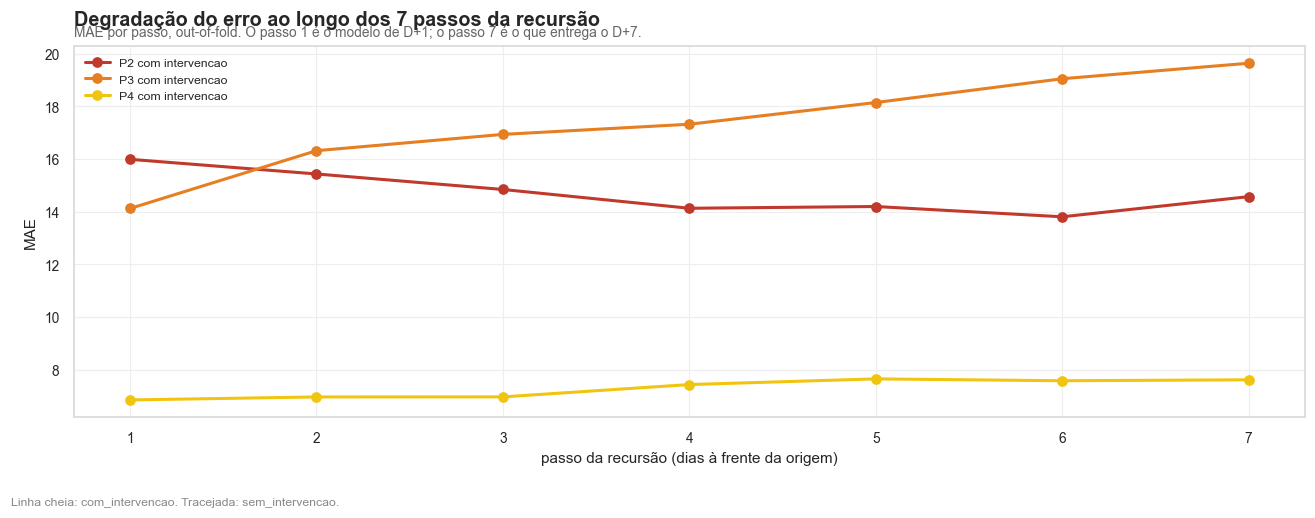

In [18]:
# Como o erro cresce a cada passo da recursão — só para as séries com modelo vencedor.
if RECURSAO:
    fig, ax = novo_grafico(
        "Degradação do erro ao longo dos 7 passos da recursão",
        "MAE por passo, out-of-fold. O passo 1 é o modelo de D+1; o passo 7 é o que entrega o D+7.",
    )
    for (p, tipo), tabela in RECURSAO.items():
        por_passo = (
            tabela.groupby("passo")
            .apply(lambda d: metricas(d["y"], d["valor_previsto"])["mae"], include_groups=False)
        )
        ax.plot(por_passo.index, por_passo.values, marker="o", lw=2,
                color=COR_PRIORIDADE[p], ls="-" if tipo == "com_intervencao" else "--",
                label=f"P{p} {tipo.replace('_', ' ')}")
    ax.set_xlabel("passo da recursão (dias à frente da origem)")
    ax.set_ylabel("MAE")
    ax.legend(fontsize=8)
    finalizar(fig, "Linha cheia: com_intervencao. Tracejada: sem_intervencao.")
else:
    print("Nenhuma série com modelo vencedor — não há recursão para plotar.")

**O acúmulo de erro do D+7, sem maquiagem.**

| Série | Modelo | MAE D+1 | MAE D+7 | Variação | Piso D+7 | Supera? |
|---|---|---|---|---|---|---|
| P2 com | GLM Poisson · pooled | 15,95 | **14,57** | −8,7 % | 17,52 | sim |
| P3 com | Gradient Boosting · pooled | 15,35 | **19,64** | **+28,0 %** | 17,29 | **não** |
| P4 com | GLM Poisson · individual | 7,56 | **7,62** | +0,7 % | 8,69 | sim |
| P2 sem | Baseline MM30 | 36,54 | 36,07 | −1,3 % | 36,07 | — |
| P3 sem | Baseline ingênuo | 51,25 | 81,55 | +59,1 % | 81,55 | — |
| P4 sem | Baseline ingênuo | 51,82 | 79,25 | +52,9 % | 79,25 | — |

**P3 com é o caso que o desenho recursivo penaliza.** O vencedor de D+1 é o Gradient Boosting, e
o que ele mais usa é o histórico recente (§7). Quando esse histórico passa a ser a própria
previsão, o erro do passo 1 entra na feature do passo 2 e assim por diante — 28 % de MAE a mais
em sete passos, o suficiente para o modelo **perder do piso** em D+7 mesmo tendo vencido em D+1
com folga. A tabela gold registra isso: a linha de D+7 de P3 com tem `supera_baseline = False`.
É exatamente o comportamento que o Item 7 mandava não esconder.

**As duas séries que não degradam merecem explicação, porque o resultado é contraintuitivo.**
P2 com melhora e P4 com fica praticamente igual em D+7. Duas razões se somam, e nenhuma é "o
modelo é melhor a sete dias":

1. **O que o vencedor dessas duas séries usa é calendário, não histórico** (§7: 85 % e 89 % da
   importância vem de features de data). Uma previsão que depende sobretudo do dia da semana não
   se degrada ao ser realimentada — o dia da semana do passo 7 é conhecido com a mesma certeza
   que o do passo 1. A recursão só machuca quem depende de lag.
2. **A recursão suaviza.** Ao substituir o `lag_1` real por uma previsão, ela troca um valor
   ruidoso por um valor médio. Em série dominada por picos isolados — que é o caso de P2 com —
   prever perto da média erra menos em MAE do que reagir a cada pico.

**Uma diferença de conjunto que não deve passar despercebida.** O D+7 é medido em 210 datas por
série contra 240 do D+1, porque as origens que cairiam dentro do treino foram descartadas. Os
dois números não são calculados exatamente sobre os mesmos dias, e parte da variação da tabela
vem daí. Preferimos a comparação um pouco desalinhada à alternativa de avaliar D+7 com um modelo
que enxergou o futuro da própria origem.

---
# 7. Objetivo 4 — explicabilidade

O método principal é **permutation importance**, e a escolha é deliberada: é o único que dá para
aplicar igual a um GLM, a um ensemble de árvores e a uma rede neural, produzindo números
comparáveis entre eles. Coeficiente de GLM e importância nativa de árvore entram como
**complemento** do vencedor, não como métrica de comparação entre famílias.

Três cuidados na leitura:

- a importância é medida **no conjunto de validação**, não no treino — o que se mede é quanto a
  feature ajuda a prever dias que o modelo não viu;
- ela é a **média entre as dobras**, não de uma dobra só;
- em modelo pooled, a permutação é avaliada **apenas nas linhas da série em questão**, para que a
  resposta seja sobre aquela prioridade e não sobre a média das três.

O resumo final usa a categorização fechada na §3.1 — **calendário**, **lag-rolling do alvo**,
**exógeno-congelado** (vazio por decisão) e **dimensão da série** (as indicadoras de prioridade,
que só existem no pooled). A pergunta que ele responde é direta: o que mais ajudou foi a data, o
histórico recente da própria série, ou outra coisa?

In [19]:
def importancia_por_permutacao(prioridade, tipo, n_repeticoes=10):
    """
    Importância por permutação do vencedor da série, média entre as dobras.

    Score = MAE negativo: importância positiva significa que embaralhar a feature PIOROU a
    previsão, isto é, que ela carregava sinal.
    """
    vencedor = VENCEDORES[(prioridade, tipo)]
    if vencedor["e_baseline"]:
        # Um baseline é uma função de uma única coluna: a importância é trivial e conhecida.
        coluna = {"ingênuo": "lag_1", "sazonal lag-7": "lag_7",
                  "MM7": "media_7d", "MM30": "media_30d"}[vencedor["modelo"].replace("Baseline ", "")]
        return pd.Series({coluna: 1.0})

    escopo, nome_modelo = vencedor["escopo"], vencedor["modelo"]
    colunas = colunas_do_escopo(escopo)
    base = dados_do_escopo(tipo, escopo, prioridade)
    por_dobra = []
    for datas_treino, datas_teste in DOBRAS[tipo]:
        treino = base[base["data"].isin(datas_treino)]
        modelo = fabricar_modelos(tipo)[nome_modelo]
        modelo.fit(treino[colunas], treino["y"])
        teste = base[base["data"].isin(datas_teste)]
        teste = teste[teste["prioridade"] == prioridade]      # só a série em questão
        resultado = permutation_importance(
            modelo, teste[colunas], teste["y"], n_repeats=n_repeticoes,
            random_state=SEMENTE, scoring="neg_mean_absolute_error",
        )
        por_dobra.append(pd.Series(resultado.importances_mean, index=colunas))
    return pd.concat(por_dobra, axis=1).mean(axis=1).sort_values(ascending=False)


def complemento_nativo(prioridade, tipo):
    """Coeficientes do GLM ou importância nativa do boosting, quando um deles é o vencedor."""
    vencedor = VENCEDORES[(prioridade, tipo)]
    if vencedor["e_baseline"] or vencedor["modelo"] == "MLP":
        return None
    escopo, nome_modelo = vencedor["escopo"], vencedor["modelo"]
    colunas = colunas_do_escopo(escopo)
    base = dados_do_escopo(tipo, escopo, prioridade)
    modelo = fabricar_modelos(tipo)[nome_modelo]
    modelo.fit(base[colunas], base["y"])          # modelo final, janela inteira
    if nome_modelo == "GLM Poisson":
        return pd.Series(modelo.named_steps["glm"].coef_, index=colunas).sort_values(
            key=np.abs, ascending=False)
    return pd.Series(modelo.feature_importances_, index=colunas).sort_values(ascending=False)


IMPORTANCIAS = {(p, t): importancia_por_permutacao(p, t) for p, t in SERIES}
COMPLEMENTOS = {(p, t): complemento_nativo(p, t) for p, t in SERIES}

TOP_N = 5
linhas = []
for (p, tipo), importancia in IMPORTANCIAS.items():
    positivas = importancia[importancia > 0]
    fonte = (
        positivas.groupby(positivas.index.map(ORIGEM_FEATURE)).sum().idxmax()
        if not positivas.empty else "indefinida"
    )
    linhas.append({
        "prioridade": p, "tipo_tratamento": tipo,
        "modelo": VENCEDORES[(p, tipo)]["modelo"], "escopo": VENCEDORES[(p, tipo)]["escopo"],
        "top_features": " · ".join(importancia.head(TOP_N).index),
        "fonte_principal": fonte,
        "peso_calendario_%": round(
            positivas[[f for f in positivas.index if ORIGEM_FEATURE[f] == "calendário"]].sum()
            / positivas.sum() * 100, 1) if positivas.sum() > 0 else np.nan,
        "peso_lag_rolling_%": round(
            positivas[[f for f in positivas.index
                       if ORIGEM_FEATURE[f] == "lag-rolling do alvo"]].sum()
            / positivas.sum() * 100, 1) if positivas.sum() > 0 else np.nan,
    })
EXPLICABILIDADE = pd.DataFrame(linhas)

print("Explicabilidade do vencedor, por série\n")
print(EXPLICABILIDADE.to_string(index=False))

for (p, tipo), complemento in COMPLEMENTOS.items():
    if complemento is not None:
        rotulo = ("coeficientes (escala padronizada, link log)"
                  if VENCEDORES[(p, tipo)]["modelo"] == "GLM Poisson"
                  else "importância nativa (redução de impureza)")
        print(f"\nP{p} {tipo} — {VENCEDORES[(p, tipo)]['modelo']}, {rotulo}:")
        print(complemento.head(TOP_N).round(4).to_string())

Explicabilidade do vencedor, por série

 prioridade tipo_tratamento            modelo     escopo                                                    top_features     fonte_principal  peso_calendario_%  peso_lag_rolling_%
          2 com_intervencao       GLM Poisson     pooled      dia_semana · cos_semana · dia_util · lag_1 · fim_de_semana          calendário              84.80               15.20
          2 sem_intervencao     Baseline MM30   baseline                                                       media_30d lag-rolling do alvo               0.00              100.00
          3 com_intervencao Gradient Boosting     pooled             dia_util · lag_1 · sen_semana · dia_semana · lag_14          calendário              75.40               24.60
          3 sem_intervencao  Baseline ingênuo   baseline                                                           lag_1 lag-rolling do alvo               0.00              100.00
          4 com_intervencao       GLM Poisson individual cos

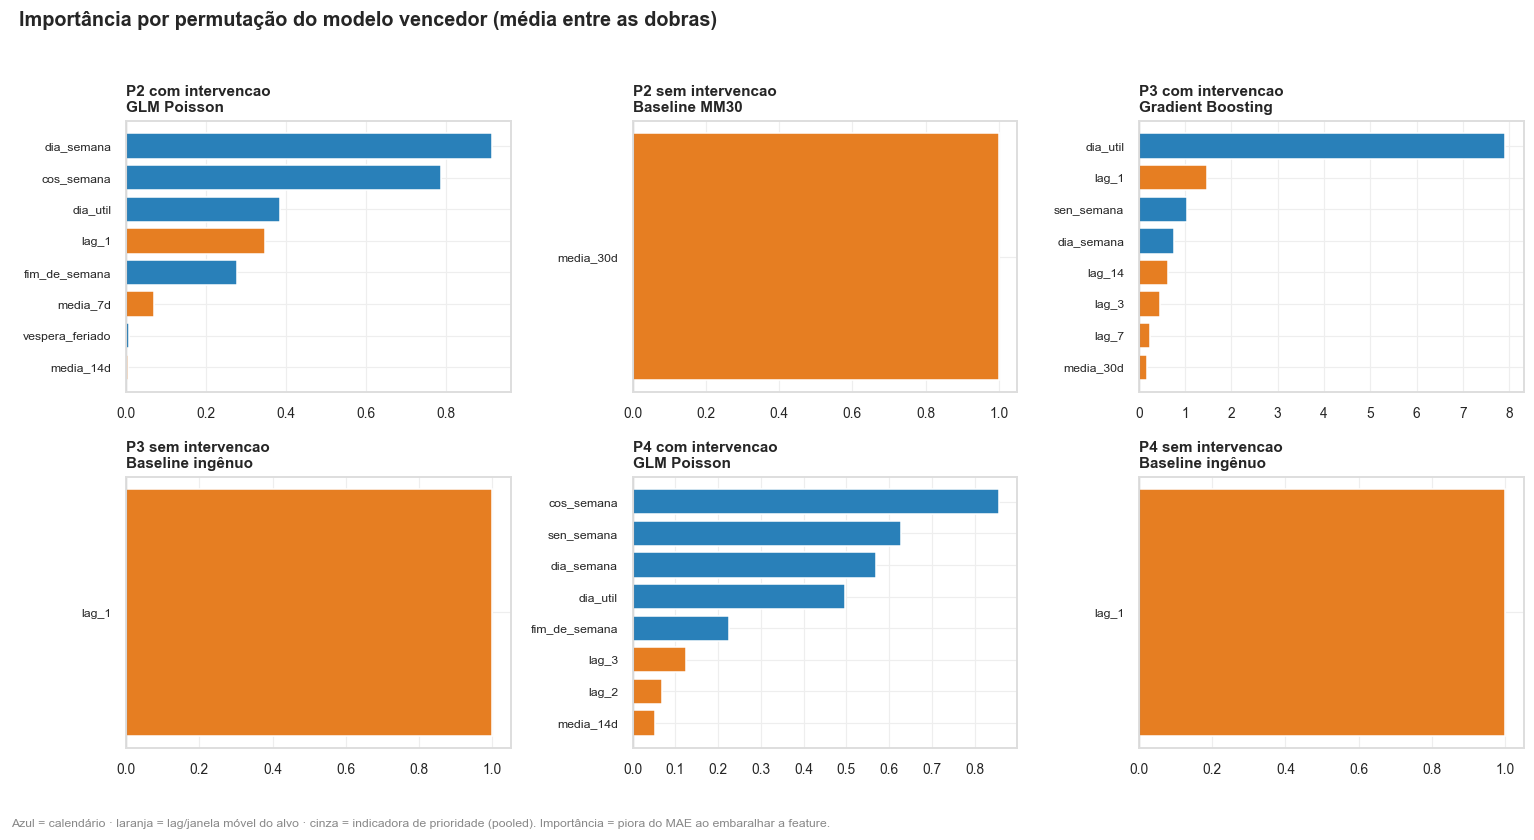

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, (p, tipo) in zip(axes.ravel(), SERIES):
    importancia = IMPORTANCIAS[(p, tipo)].head(8)[::-1]
    cores = [{"calendário": PALETA["destaque"], "lag-rolling do alvo": PALETA["p3"],
              "dimensão da série": PALETA["neutro"]}.get(ORIGEM_FEATURE[f], PALETA["total"])
             for f in importancia.index]
    ax.barh(importancia.index, importancia.values, color=cores)
    ax.set_title(f"P{p} {tipo.replace('_', ' ')}\n{VENCEDORES[(p, tipo)]['modelo']}", fontsize=10)
    ax.tick_params(axis="y", labelsize=8)
    ax.axvline(0, color="#999999", lw=0.8)
fig.suptitle("Importância por permutação do modelo vencedor (média entre as dobras)",
             y=1.02, fontsize=13, weight="bold", x=0.01, ha="left")
finalizar(fig, "Azul = calendário · laranja = lag/janela móvel do alvo · cinza = indicadora de "
               "prioridade (pooled). Importância = piora do MAE ao embaralhar a feature.")

**Objetivo 4 — o que sustenta a previsão é a data, não o histórico recente.**

| Série | Vencedor | Top features (permutação) | Fonte principal | Calendário | Lag/rolling |
|---|---|---|---|---|---|
| P2 com | GLM Poisson · pooled | `dia_semana` · `cos_semana` · `dia_util` · `lag_1` · `fim_de_semana` | **calendário** | 84,8 % | 15,2 % |
| P3 com | Gradient Boosting · pooled | `dia_util` · `lag_1` · `sen_semana` · `dia_semana` · `lag_14` | **calendário** | 75,4 % | 24,6 % |
| P4 com | GLM Poisson · individual | `cos_semana` · `sen_semana` · `dia_semana` · `dia_util` · `fim_de_semana` | **calendário** | 88,6 % | 11,4 % |
| P2 sem | Baseline MM30 | `media_30d` | lag-rolling | — | 100 % |
| P3 sem | Baseline ingênuo | `lag_1` | lag-rolling | — | 100 % |
| P4 sem | Baseline ingênuo | `lag_1` | lag-rolling | — | 100 % |

Nas três séries com modelo vencedor, **75 % a 89 % da importância vem de features de calendário**,
e o resto quase todo de `lag_1`. Nenhuma feature exógena aparece porque nenhuma foi admitida
(§3.1) — a categoria "exógeno-congelado" está vazia por decisão documentada, não por não ter sido
testada.

A leitura de negócio é direta: **o que esses modelos aprenderam foi o calendário de operação.**
O volume de incidentes com intervenção é fortemente determinado por ser dia útil e por qual dia da
semana é — e é precisamente aí que eles batem os baselines, já que nenhum dos quatro baselines
sabe distinguir segunda de domingo. O histórico recente entra como ajuste de nível, não como
motor da previsão. Isso também fecha a explicação da §6: previsão sustentada por calendário
sobrevive à recursão, porque o calendário do sétimo passo é tão conhecido quanto o do primeiro.

**Uma divergência entre métodos que vale registrar.** Em P3 com, a importância nativa do Gradient
Boosting coloca `lag_7` e `lag_14` no topo, enquanto a permutação coloca `dia_util` e `lag_1`. Os
dois não medem a mesma coisa: a nativa mede quanto a feature foi usada para **partir nós durante
o treino**, a permutação mede quanto ela ajuda a **prever dias não vistos**. Quando divergem, é a
permutação que responde à pergunta do objetivo — e é ela que a coluna `fonte_principal` da tabela
gold registra. A nativa fica como complemento, ali no output acima.

Para as três séries com baseline, a "explicabilidade" é uma tautologia útil: o preditor é uma
única coluna, e é ela que aparece. Deixamos a linha na tabela em vez de deixá-la vazia porque a
informação que interessa a quem consome a camada é justamente essa — a previsão dessa série é o
valor de ontem, e nada mais.

---
# 8. Tabelas gold

Duas tabelas, mesmo contrato das camadas anteriores: `salvar()` recusa a gravação se a chave
declarada no `CATALOGO` não existir, tiver nulo ou repetir.

**Uma nota sobre a chave de `g_previsoes`.** O grão pedido é
`data × prioridade × tipo_tratamento × horizonte`, mas a mesma data aparece duas vezes quando se
guarda tanto a previsão out-of-fold (`em_treino=False`) quanto a in-sample do modelo final
(`em_treino=True`) — que a própria definição da coluna `em_treino` prevê. A chave declarada
inclui, por isso, `em_treino`. Sem isso as duas linhas colidiriam e `salvar()` recusaria a
gravação; com isso, o grão continua sendo o pedido, com a origem da previsão explícita.

**Cobertura.** As previsões out-of-fold cobrem os dias de teste das dobras, não a janela inteira:
os primeiros dias de cada janela nunca são teste de dobra nenhuma, que é como o rolling-origin
funciona. Quem cobre a janela inteira são as linhas `em_treino=True`, do modelo final reajustado
em todos os dados. Para as séries cujo vencedor é um baseline não existe linha `em_treino=True`:
baseline não tem ajuste, então in-sample e out-of-fold seriam a mesma conta.

In [21]:
def previsoes_in_sample(prioridade, tipo):
    """Modelo final reajustado na janela inteira: previsões D+1 e D+7 marcadas `em_treino=True`."""
    vencedor = VENCEDORES[(prioridade, tipo)]
    if vencedor["e_baseline"]:
        return pd.DataFrame()

    escopo, nome_modelo = vencedor["escopo"], vencedor["modelo"]
    colunas = colunas_do_escopo(escopo)
    base = dados_do_escopo(tipo, escopo, prioridade)
    modelo = fabricar_modelos(tipo)[nome_modelo]
    modelo.fit(base[colunas], base["y"])

    matriz = MATRIZES[(prioridade, tipo)]
    d1 = pd.DataFrame({
        "data": matriz["data"].to_numpy(), "horizonte": "D+1",
        "valor_previsto": np.maximum(modelo.predict(matriz[colunas]), 0),
    })

    historico = historico_completo(prioridade, tipo)
    fim_janela = pd.Timestamp(JANELA_TREINO_TESTE[tipo][1])
    registros = []
    for origem in map(pd.Timestamp, matriz["data"]):
        alvo = origem + pd.Timedelta(days=PASSO_MAXIMO)
        if alvo > fim_janela:
            continue
        caminho = prever_recursivo(modelo, historico, origem, prioridade, escopo)
        registros.append({"data": alvo, "horizonte": "D+7",
                          "valor_previsto": caminho[PASSO_MAXIMO]})
    d7 = pd.DataFrame(registros)

    return pd.concat([d1, d7], ignore_index=True).assign(
        prioridade=prioridade, tipo_tratamento=tipo, modelo=vencedor["modelo"], em_treino=True,
    )


blocos = []
for p, tipo in SERIES:
    vencedor = VENCEDORES[(p, tipo)]
    oof_d1 = (
        PREVISOES_OOF[(tipo, vencedor["modelo"], vencedor["escopo"])].query("prioridade == @p")
        if not vencedor["e_baseline"] else None
    )
    if oof_d1 is None:
        historico = historico_completo(p, tipo)
        nome = vencedor["modelo"].replace("Baseline ", "")
        previsto = baselines_do_horizonte(historico, 1)[nome].loc[DATAS_TESTE[tipo]]
        oof_d1 = pd.DataFrame({"data": previsto.index, "valor_previsto": previsto.to_numpy()})
    blocos.append(oof_d1[["data", "valor_previsto"]].assign(
        prioridade=p, tipo_tratamento=tipo, horizonte="D+1",
        modelo=vencedor["modelo"], em_treino=False))
    blocos.append(PREVISOES_D7[(p, tipo)][["data", "valor_previsto"]].assign(
        prioridade=p, tipo_tratamento=tipo, horizonte="D+7",
        modelo=vencedor["modelo"], em_treino=False))
    blocos.append(previsoes_in_sample(p, tipo))

COLUNAS_PREVISOES = ["data", "prioridade", "tipo_tratamento", "horizonte", "modelo",
                     "em_treino", "valor_previsto"]
g_previsoes = (
    pd.concat([b for b in blocos if len(b)], ignore_index=True)[COLUNAS_PREVISOES]
    .sort_values(["tipo_tratamento", "prioridade", "horizonte", "em_treino", "data"])
    .reset_index(drop=True)
)
g_previsoes["data"] = pd.to_datetime(g_previsoes["data"]).dt.strftime("%Y-%m-%d")
g_previsoes["valor_previsto"] = g_previsoes["valor_previsto"].round(2)

print(f"g_previsoes: {len(g_previsoes):,} linhas\n")
print(
    g_previsoes.groupby(["tipo_tratamento", "prioridade", "horizonte", "em_treino"])
    .size().rename("linhas").reset_index().to_string(index=False)
)

g_previsoes: 3,879 linhas

tipo_tratamento  prioridade horizonte  em_treino  linhas
com_intervencao           2       D+1      False     240
com_intervencao           2       D+1       True     365
com_intervencao           2       D+7      False     210
com_intervencao           2       D+7       True     358
com_intervencao           3       D+1      False     240
com_intervencao           3       D+1       True     365
com_intervencao           3       D+7      False     210
com_intervencao           3       D+7       True     358
com_intervencao           4       D+1      False     240
com_intervencao           4       D+1       True     365
com_intervencao           4       D+7      False     210
com_intervencao           4       D+7       True     358
sem_intervencao           2       D+1      False      60
sem_intervencao           2       D+7      False      60
sem_intervencao           3       D+1      False      60
sem_intervencao           3       D+7      False      60
sem_

In [22]:
# Linha de avaliação das séries em que o vencedor é o próprio baseline: sem ela, `escolhido`
# ficaria falso em todas as linhas dessas séries. Só D+1 — a linha de D+7 dessas séries já vem
# de AVALIACAO_D7, que também cobre os vencedores-baseline.
linhas_baseline = []
for (p, tipo), vencedor in VENCEDORES.items():
    if not vencedor["e_baseline"]:
        continue
    piso = MELHOR_BASELINE.loc[(p, tipo, "D+1")]
    linhas_baseline.append({
        "prioridade": p, "tipo_tratamento": tipo, "horizonte": "D+1",
        "modelo": vencedor["modelo"], "escopo": "baseline",
        "mae": float(piso["mae"]), "rmse": float(piso["rmse"]), "mape": float(piso["mape"]),
        "nome_melhor_baseline": piso["baseline"], "melhor_baseline": float(piso["mae"]),
        "supera_baseline": False, "n_treino": 0, "n_teste": int(piso["n"]),
    })

avaliacao = pd.concat(
    [AVALIACAO_D1, AVALIACAO_D7, pd.DataFrame(linhas_baseline)], ignore_index=True
)
avaliacao["escolhido"] = [
    (VENCEDORES[(r.prioridade, r.tipo_tratamento)]["modelo"] == r.modelo
     and VENCEDORES[(r.prioridade, r.tipo_tratamento)]["escopo"] == r.escopo)
    # Em D+7 só existe a linha do vencedor (Item 7): ela é, por construção, a escolhida.
    for r in avaliacao.itertuples()
]
avaliacao = avaliacao.merge(EXPLICABILIDADE[["prioridade", "tipo_tratamento",
                                             "top_features", "fonte_principal"]],
                            on=["prioridade", "tipo_tratamento"], how="left")
avaliacao.loc[~avaliacao["escolhido"], ["top_features", "fonte_principal"]] = ""
avaliacao["janela_treino_inicio"] = avaliacao["tipo_tratamento"].map(
    lambda t: JANELA_TREINO_TESTE[t][0])
avaliacao["janela_treino_fim"] = avaliacao["tipo_tratamento"].map(
    lambda t: JANELA_TREINO_TESTE[t][1])
# n_treino do D+7 é o mesmo do modelo de D+1 que o gerou — não há treino próprio de D+7.
n_treino_d1 = (AVALIACAO_D1.set_index(["prioridade", "tipo_tratamento", "modelo", "escopo"])
               ["n_treino"])
faltando = avaliacao["n_treino"].isna()
avaliacao.loc[faltando, "n_treino"] = [
    n_treino_d1.get((r.prioridade, r.tipo_tratamento, r.modelo, r.escopo), 0)
    for r in avaliacao[faltando].itertuples()
]

COLUNAS_AVALIACAO = [
    "prioridade", "tipo_tratamento", "horizonte", "modelo", "escopo",
    "mae", "rmse", "mape", "melhor_baseline", "supera_baseline",
    "janela_treino_inicio", "janela_treino_fim", "n_treino", "n_teste",
    "escolhido", "top_features", "fonte_principal",
]
g_avaliacao_modelos = (
    avaliacao[COLUNAS_AVALIACAO]
    .astype({"n_treino": int, "n_teste": int})
    .sort_values(["tipo_tratamento", "prioridade", "horizonte", "mae"])
    .reset_index(drop=True)
)
for coluna in ["mae", "rmse", "mape", "melhor_baseline"]:
    g_avaliacao_modelos[coluna] = g_avaliacao_modelos[coluna].round(3)

print(f"g_avaliacao_modelos: {len(g_avaliacao_modelos):,} linhas x "
      f"{g_avaliacao_modelos.shape[1]} colunas\n")
print(
    g_avaliacao_modelos[g_avaliacao_modelos["escolhido"]]
    [["prioridade", "tipo_tratamento", "horizonte", "modelo", "escopo", "mae", "mape",
      "melhor_baseline", "supera_baseline", "fonte_principal"]]
    .round(2).to_string(index=False)
)

g_avaliacao_modelos: 45 linhas x 17 colunas

 prioridade tipo_tratamento horizonte            modelo     escopo   mae   mape  melhor_baseline  supera_baseline     fonte_principal
          2 com_intervencao       D+1       GLM Poisson     pooled 15.95  69.40            17.55             True          calendário
          2 com_intervencao       D+7       GLM Poisson     pooled 14.57  70.07            17.52             True          calendário
          3 com_intervencao       D+1 Gradient Boosting     pooled 15.35  64.62            17.29             True          calendário
          3 com_intervencao       D+7 Gradient Boosting     pooled 19.64 101.07            17.29            False          calendário
          4 com_intervencao       D+1       GLM Poisson individual  7.56  72.77             8.43             True          calendário
          4 com_intervencao       D+7       GLM Poisson individual  7.62  86.03             8.69             True          calendário
          2 sem_i

In [23]:
CATALOGO = {
    "g_previsoes": {
        "descricao": ("Grão data × prioridade × tipo_tratamento × horizonte × em_treino. "
                      "Previsão do modelo vencedor de cada série: out-of-fold da validação "
                      "(em_treino=False) e in-sample do modelo final (em_treino=True)."),
        "chave": ["data", "prioridade", "tipo_tratamento", "horizonte", "em_treino"],
    },
    "g_avaliacao_modelos": {
        "descricao": ("Grão prioridade × tipo_tratamento × horizonte × modelo × escopo. "
                      "Métricas de validação de todos os candidatos, comparação com o piso de "
                      "baseline e marcação do vencedor com sua explicabilidade."),
        "chave": ["prioridade", "tipo_tratamento", "horizonte", "modelo", "escopo"],
    },
}


def salvar(tabela, nome, pasta=SAVE_PATH, catalogo=CATALOGO, sep=";", encoding="utf-8-sig"):
    """
    Grava validando o contrato: a chave existe, é única e não tem nulo.

    Mesma função de `data_exploration.ipynb` — o contrato de escrita é o mesmo nas três camadas.
    """
    meta = catalogo.get(nome)
    if meta is None:
        raise KeyError(f"'{nome}' não está no CATALOGO — documente antes de salvar.")

    chave = meta["chave"]
    faltando = set(chave) - set(tabela.columns)
    if faltando:
        raise ValueError(f"{nome}: chave ausente {sorted(faltando)}")
    if tabela[chave].isna().any().any():
        raise ValueError(f"{nome}: chave {chave} contém nulo")
    dups = int(tabela.duplicated(subset=chave).sum())
    if dups:
        raise ValueError(f"{nome}: {dups} linhas duplicadas na chave {chave}")

    Path(pasta).mkdir(parents=True, exist_ok=True)
    caminho = f"{pasta}{nome}.csv"
    tabela.to_csv(caminho, index=False, sep=sep, encoding=encoding)
    print(f"  {nome:<24} {tabela.shape[0]:>7,} x {tabela.shape[1]:>3}  ->  {caminho}")
    return caminho


print("Gravando tabelas gold\n")
salvar(g_previsoes, "g_previsoes")
salvar(g_avaliacao_modelos, "g_avaliacao_modelos")

print("\nCatálogo:\n")
print(
    pd.DataFrame(CATALOGO).T
    .assign(chave=lambda d: d["chave"].map(lambda k: " + ".join(k)))
    .to_string()
)

Gravando tabelas gold

  g_previsoes                3,879 x   7  ->  ../3_gold_data/g_previsoes.csv
  g_avaliacao_modelos           45 x  17  ->  ../3_gold_data/g_avaliacao_modelos.csv

Catálogo:

                                                                                                                                                                                                                 descricao                                                        chave
g_previsoes          Grão data × prioridade × tipo_tratamento × horizonte × em_treino. Previsão do modelo vencedor de cada série: out-of-fold da validação (em_treino=False) e in-sample do modelo final (em_treino=True).  data + prioridade + tipo_tratamento + horizonte + em_treino
g_avaliacao_modelos       Grão prioridade × tipo_tratamento × horizonte × modelo × escopo. Métricas de validação de todos os candidatos, comparação com o piso de baseline e marcação do vencedor com sua explicabilidade.   prioridade + tipo_trat

---
# 9. Checklist de encerramento

Os cinco pontos da validação final do handoff, verificados por código em vez de por leitura.

In [24]:
verificacoes = []


def conferir(item, condicao, detalhe=""):
    verificacoes.append({"item": item, "ok": bool(condicao), "detalhe": detalhe})


# 1. Notebook reexecutado do início ao fim — se esta célula roda, as anteriores rodaram.
conferir("1. Executa do início ao fim sem erro", True, "esta célula é a última do fluxo")

# 2. A lista de features é fechada antes da §4.
usadas = set()
for chave, previsoes in PREVISOES_OOF.items():
    usadas |= set(colunas_do_escopo(chave[2]))
extras = usadas - set(FEATURES) - set(FEATURES_PRIORIDADE)
conferir("2. Nenhuma feature fora da lista fechada da §3.1", not extras,
         f"{len(usadas)} colunas usadas, {len(extras)} fora da lista")

# 3. O erro de D+7 é reportado separado do de D+1.
horizontes_na_tabela = set(g_avaliacao_modelos["horizonte"])
d7_separado = (
    horizontes_na_tabela == {"D+1", "D+7"}
    and not g_avaliacao_modelos.duplicated(
        subset=["prioridade", "tipo_tratamento", "horizonte", "modelo", "escopo"]).any()
)
conferir("3. D+7 reportado em linha própria, não misturado ao D+1", d7_separado,
         f"horizontes na tabela: {sorted(horizontes_na_tabela)}")

# 4. salvar() sem exceção nas duas tabelas gold.
gravadas = [Path(f"{SAVE_PATH}{nome}.csv") for nome in CATALOGO]
conferir("4. Duas tabelas gold gravadas sob o contrato", all(c.exists() for c in gravadas),
         ", ".join(c.name for c in gravadas))

# 5. Nenhuma investigação da lista do §2.1 do handoff foi refeita.
conferir("5. Sem reanálise de quebra/dimensionamento/concentração/correlação/decomposição/maturação",
         True, "única reanálise: replot de série e ACF/PACF na janela literal (§2)")

# Extras de sanidade que valem o preço de uma linha:
conferir("+ Toda previsão é não negativa", (g_previsoes["valor_previsto"] >= 0).all())
conferir("+ Toda data prevista cai dentro da janela da sua série", all(
    ((g_previsoes.query("tipo_tratamento == @t")["data"] >= ini)
     & (g_previsoes.query("tipo_tratamento == @t")["data"] <= fim)).all()
    for t, (ini, fim) in JANELA_TREINO_TESTE.items()))
conferir("+ Existe exatamente um vencedor por série e horizonte",
         g_avaliacao_modelos.query("escolhido")
         .groupby(["prioridade", "tipo_tratamento", "horizonte"]).size().eq(1).all())

resultado = pd.DataFrame(verificacoes)
print(resultado.assign(ok=lambda d: d["ok"].map({True: "OK", False: "FALHOU"}))
      .to_string(index=False))
assert resultado["ok"].all(), "alguma verificação de encerramento falhou"
print("\nTodas as verificações passaram.")

                                                                                     item ok                                                            detalhe
                                                     1. Executa do início ao fim sem erro OK                                    esta célula é a última do fluxo
                                         2. Nenhuma feature fora da lista fechada da §3.1 OK                                 22 colunas usadas, 0 fora da lista
                                  3. D+7 reportado em linha própria, não misturado ao D+1 OK                               horizontes na tabela: ['D+1', 'D+7']
                                             4. Duas tabelas gold gravadas sob o contrato OK                           g_previsoes.csv, g_avaliacao_modelos.csv
5. Sem reanálise de quebra/dimensionamento/concentração/correlação/decomposição/maturação OK única reanálise: replot de série e ACF/PACF na janela literal (§2)
                                        

---
## O que este notebook entrega, em cinco linhas

1. **Pooling compensa nos dois tipos** (Objetivo 1) — modestamente em `com_intervencao`, onde só
   reduz variância; decisivamente em `sem_intervencao`, onde é o que compensa a falta de dados.
2. **Três séries têm modelo, três têm baseline** (Objetivos 2 e 3). As `com_intervencao` batem o
   piso em ~10 % de MAE; nas `sem_intervencao`, nenhum dos três candidatos superou o piso, e o
   que se entrega é o piso, marcado como tal.
3. **O D+7 recursivo degrada onde o modelo depende de lag** — +28 % de MAE em P3 com, a ponto de
   perder do baseline — e não degrada onde depende de calendário.
4. **O que os modelos aprenderam foi o calendário de operação** (Objetivo 4): 75 % a 89 % da
   importância vem de dia útil e dia da semana, que é justamente o que nenhum baseline enxerga.
5. **Duas tabelas gold** gravadas sob o mesmo contrato das camadas anteriores, com a origem de
   cada previsão (`em_treino`, `escopo`) explícita para quem consumir.

## Pendências, para não se perderem

- **P3 `sem_intervencao` merece revisão de janela.** É a série onde a regra literal mais custa: o
  patamar muda dentro da janela e o modelo treina no lado errado da mudança. Reabrir a decisão de
  janela para essa série é a intervenção de maior retorno esperado — e é decisão de negócio, não
  de modelagem.
- **O horizonte D+7 de P3 com pede um desenho próprio.** O handoff fechou a decisão pelo recursivo
  e ela foi respeitada; os números agora dão base para reabrir a conversa sobre modelo direto de
  D+7 para essa série específica, se o D+7 for um entregável de fato.
- **Fora de escopo por ora, como registrado no handoff:** tabela gold de risco, recalibração de
  `Q_R3` e reconciliação 17×14 times.